# MIMIC-II IAC Introduction

This tutorial explores the **M**ultiparameter **I**ntelligent **M**onitoring in **I**ntensive **C**are II (**MIMIC-II**) **I**ndwelling **A**rterial **C**atheters (**IAC**) dataset, as subset derived from MIMIC-II, the publicly-accessible critical care database.
The database was created for the purpose of a case study in the book ["Secondary Analysis of Electronic Health Records"](https://link.springer.com/book/10.1007/978-3-319-43742-2), published by Springer in 2016.
In particular, the MIMIC-II IAC dataset was used throughout Chapter 16 (Data Analysis) by Raffa J. et al. to investigate the effectiveness of indwelling arterial catheters in hemodynamically stable patients with respiratory failure for mortality outcomes. 

More details on the dataset such as all included features and their description can be found [here](https://physionet.org/content/mimic2-iaccd/1.0/).

In [4]:
import warnings

warnings.filterwarnings("ignore")

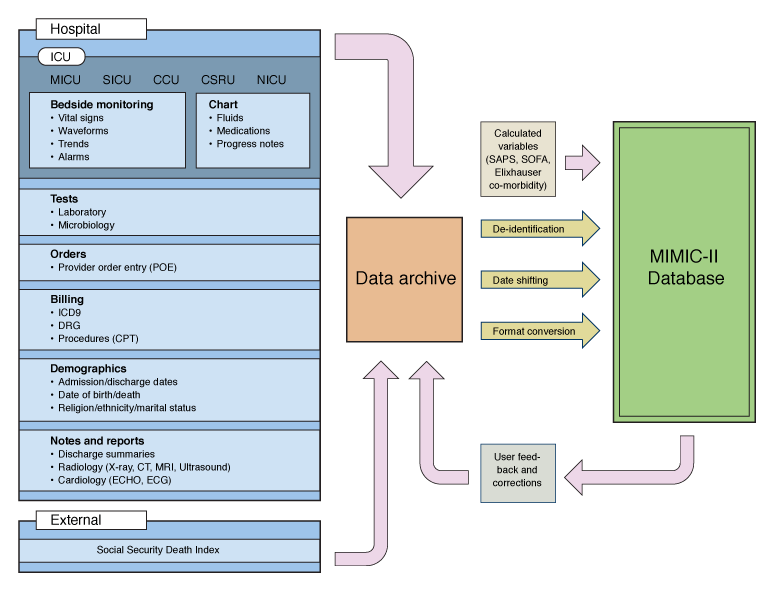

In [65]:
from IPython.display import Image

Image(filename="images/MIMIC-II-database-structure.png", width=400)

In this tutorial we want to explore the MIMIC-II IAC dataset using ehrapy to identify patient groups and their associated features. 

The major steps of an analysis with ehrapy include:

1. Preprocessing and quality control (QC)
   
2. Dimensionality reduction
   
3. Batch effect identification
   
4. Clustering
   
5. Additional downstream analysis

Before we start with the analysis of the MIMIC-II IAC dataset, we set up our environment including the import of packages and preparation of the dataset.

_________________

## Environment setup

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
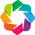

In [5]:
import warnings

warnings.filterwarnings("ignore")

import ehrapy as ep
import ehrdata as ed
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### MIMIC-II IAC dataset loading

`ehrdata` offers several [datasets](https://ehrdata.readthedocs.io/en/latest/api/datasets_index.html) in EHRData format that can be used out of the box.
In this tutorial we will use the MIMIC-II IAC dataset with unencoded features. ehrapy's default encoding is a simple one-hot encoding in this case. More details on encoding can be seen in the next step.

In [6]:
edata = ed.dt.mimic_2()
edata

EHRData object with n_obs × n_vars × n_t = 1776 × 46 × 1
    shape of .X: (1776, 46)

The MIMIC-II dataset has 1776 patients with 46 features. 
<br>
Now that we have our EHRData file ready, we can start the analysis using ehrapy and the first step will be to preprocess the dataset.

## Analysis using ehrapy

### Preprocessing

In [7]:
ed.infer_feature_types(edata, binary_as="numeric")

! Feature  was detected as categorical features stored numerically. Adjust using `ed.replace_feature_types` if needed.


 Detected feature types for EHRData object with 1776 obs and 46 vars
╠══ 📅 Date features
╠══ 📐 Numerical features
║   ╠══ abg_count
║   ╠══ afib_flg
║   ╠══ age
║   ╠══ aline_flg
║   ╠══ bmi
║   ╠══ bun_first
║   ╠══ cad_flg
║   ╠══ censor_flg
║   ╠══ chf_flg
║   ╠══ chloride_first
║   ╠══ copd_flg
║   ╠══ creatinine_first
║   ╠══ day_28_flg
║   ╠══ day_icu_intime_num
║   ╠══ gender_num
║   ╠══ hgb_first
║   ╠══ hosp_exp_flg
║   ╠══ hospital_los_day
║   ╠══ hour_icu_intime
║   ╠══ hr_1st
║   ╠══ icu_exp_flg
║   ╠══ icu_los_day
║   ╠══ iv_day_1
║   ╠══ liver_flg
║   ╠══ mal_flg
║   ╠══ map_1st
║   ╠══ mort_day_censored
║   ╠══ pco2_first
║   ╠══ platelet_first
║   ╠══ po2_first
║   ╠══ potassium_first
║   ╠══ renal_flg
║   ╠══ resp_flg
║   ╠══ sapsi_first
║   ╠══ sepsis_flg
║   ╠══ service_num
║   ╠══ sodium_first
║   ╠══ sofa_first
║   ╠══ spo2_1st
║   ╠══ stroke_flg
║   ╠══ tco2_first
║   ╠══ temp_1st
║   ╠══ wbc_first
║   ╚══ weight_first
╚══ 🗂️ Categorical features
    ╠══ day_icu_intime (7 categories)
    ╚══ service_unit (3 categories)

Let's have a closer look at the categorical detected features:

In [8]:
edata[:, "day_icu_intime"].X

ArrayView([['Friday   '],
           ['Saturday '],
           ['Friday   '],
           ...,
           ['Tuesday  '],
           ['Wednesday'],
           ['Monday   ']], shape=(1776, 1), dtype=object)

In [9]:
edata[:, "service_unit"].X

ArrayView([['SICU'],
           ['MICU'],
           ['MICU'],
           ...,
           ['MICU'],
           ['SICU'],
           ['MICU']], shape=(1776, 1), dtype=object)

Categorical features could either already be stored numerically (e.g., as `0`/`1` for flags) or as another type such as strings. Such categorical features need an encoding. Here, we identify **service_unit** and **day_icu_intime** as categorical features stored non-numerically. We will therefore encode them first with one-hot encoding. This ensures that no ordering is preserved for the respective features. ehrapy also offers other [encoding](https://ehrapy.readthedocs.io/en/latest/usage/usage.html#encoding) functions.

In [10]:
edata = ep.pp.encode(edata, encodings={"one-hot": ["service_unit", "day_icu_intime"]})

Output()

In [11]:
edata

EHRData object with n_obs × n_vars × n_t = 1776 × 54 × 1
    obs: 'service_unit', 'day_icu_intime'
    var: 'feature_type', 'unencoded_var_names', 'encoding_mode'
    layers: 'original'
    shape of .X: (1776, 54)
    shape of .original: (1776, 54)

In [12]:
ed.feature_type_overview(edata)

 Detected feature types for EHRData object with 1776 obs and 54 vars
╠══ 📅 Date features
╠══ 📐 Numerical features
║   ╠══ abg_count
║   ╠══ afib_flg
║   ╠══ age
║   ╠══ aline_flg
║   ╠══ bmi
║   ╠══ bun_first
║   ╠══ cad_flg
║   ╠══ censor_flg
║   ╠══ chf_flg
║   ╠══ chloride_first
║   ╠══ copd_flg
║   ╠══ creatinine_first
║   ╠══ day_28_flg
║   ╠══ day_icu_intime_num
║   ╠══ gender_num
║   ╠══ hgb_first
║   ╠══ hosp_exp_flg
║   ╠══ hospital_los_day
║   ╠══ hour_icu_intime
║   ╠══ hr_1st
║   ╠══ icu_exp_flg
║   ╠══ icu_los_day
║   ╠══ iv_day_1
║   ╠══ liver_flg
║   ╠══ mal_flg
║   ╠══ map_1st
║   ╠══ mort_day_censored
║   ╠══ pco2_first
║   ╠══ platelet_first
║   ╠══ po2_first
║   ╠══ potassium_first
║   ╠══ renal_flg
║   ╠══ resp_flg
║   ╠══ sapsi_first
║   ╠══ sepsis_flg
║   ╠══ service_num
║   ╠══ sodium_first
║   ╠══ sofa_first
║   ╠══ spo2_1st
║   ╠══ stroke_flg
║   ╠══ tco2_first
║   ╠══ temp_1st
║   ╠══ wbc_first
║   ╚══ weight_first
╚══ 🗂️ Categorical features
    ╠══ day_icu_intime (7 categories); one-hot encoded
    ╚══ service_unit (3 categories); one-hot encoded

### Quality Control (QC)

#### Demographics distribution

To see if we have strong differences by demographics, we can check these features in a violin plot.

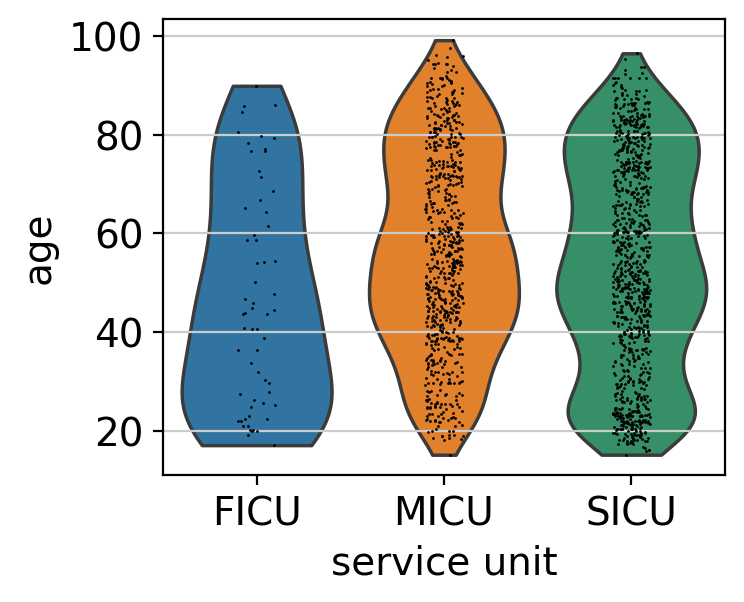

In [13]:
plt.rcParams["figure.figsize"] = (4, 3)
plt.rcParams["figure.dpi"] = 100
ep.pl.violin(edata, keys=["age"], groupby="service_unit")

#### Missing values

ehrapy's `pp.qc_metrics()` function will calculate several useful metrics such as the absolute number and percentages of missing values and properties like the mean/median/min/max of all features. The percentage of missing values is important as features with too many missing values should not be included. 

In [14]:
obs_metric, var_metrics = ep.pp.qc_metrics(edata)

In [15]:
obs_metric

,missing_values_abs,missing_values_pct,entropy_of_missingness,unique_values_abs,unique_values_ratio
0,0,0.000000,3.466198e-09,4,40.0
1,12,22.222222,7.642045e-01,4,40.0
2,0,0.000000,3.466198e-09,4,40.0
3,3,5.555556,3.095434e-01,4,40.0
4,0,0.000000,3.466198e-09,4,40.0
...,...,...,...,...,...
1771,1,1.851852,1.330396e-01,4,40.0
1772,1,1.851852,1.330396e-01,4,40.0
1773,3,5.555556,3.095434e-01,4,40.0
1774,1,1.851852,1.330396e-01,4,40.0


In [16]:
var_metrics

,missing_values_abs,missing_values_pct,entropy_of_missingness,unique_values_abs,unique_values_ratio,coefficient_of_variation,is_constant,constant_variable_ratio,range_ratio,mean,median,standard_deviation,min,max,iqr_outliers
ehrapycat_service_unit_FICU,0,0.000000,3.466198e-09,3.0,0.168919,NaN,NaN,2.272727,NaN,NaN,NaN,NaN,NaN,NaN,True
ehrapycat_service_unit_MICU,0,0.000000,3.466198e-09,3.0,0.168919,NaN,NaN,2.272727,NaN,NaN,NaN,NaN,NaN,NaN,True
ehrapycat_service_unit_SICU,0,0.000000,3.466198e-09,3.0,0.168919,NaN,NaN,2.272727,NaN,NaN,NaN,NaN,NaN,NaN,True
ehrapycat_day_icu_intime_Friday,0,0.000000,3.466198e-09,7.0,0.394144,NaN,NaN,2.272727,NaN,NaN,NaN,NaN,NaN,NaN,True
ehrapycat_day_icu_intime_Monday,0,0.000000,3.466198e-09,7.0,0.394144,NaN,NaN,2.272727,NaN,NaN,NaN,NaN,NaN,NaN,True
ehrapycat_day_icu_intime_Saturday,0,0.000000,3.466198e-09,7.0,0.394144,NaN,NaN,2.272727,NaN,NaN,NaN,NaN,NaN,NaN,True
ehrapycat_day_icu_intime_Sunday,0,0.000000,3.466198e-09,7.0,0.394144,NaN,NaN,2.272727,NaN,NaN,NaN,NaN,NaN,NaN,True
ehrapycat_day_icu_intime_Thursday,0,0.000000,3.466198e-09,7.0,0.394144,NaN,NaN,2.272727,NaN,NaN,NaN,NaN,NaN,NaN,True
ehrapycat_day_icu_intime_Tuesday,0,0.000000,3.466198e-09,7.0,0.394144,NaN,NaN,2.272727,NaN,NaN,NaN,NaN,NaN,NaN,True
ehrapycat_day_icu_intime_Wednesday,0,0.000000,3.466198e-09,7.0,0.394144,NaN,NaN,2.272727,NaN,NaN,NaN,NaN,NaN,NaN,True


All properties will be added to the respective layers. Categorical features can be found in the **obs** layer, while numerical features are in the **var** layer of the EHRData object. When inspecting both layers, we see that our QC properties were added for each feature if possible.

In [17]:
edata.obs.head(4)

,service_unit,day_icu_intime,missing_values_abs,missing_values_pct,entropy_of_missingness,unique_values_abs,unique_values_ratio
0,SICU,Friday,0,0.000000,3.466198e-09,4,40.0
1,MICU,Saturday,12,22.222222,7.642045e-01,4,40.0
2,MICU,Friday,0,0.000000,3.466198e-09,4,40.0
3,SICU,Saturday,3,5.555556,3.095434e-01,4,40.0


In [18]:
edata.var.tail(4)

,feature_type,unencoded_var_names,encoding_mode,missing_values_abs,missing_values_pct,entropy_of_missingness,unique_values_abs,unique_values_ratio,coefficient_of_variation,is_constant,constant_variable_ratio,range_ratio,mean,median,standard_deviation,min,max,iqr_outliers
creatinine_first,numeric,creatinine_first,NaN,6,0.337838,0.032600,NaN,NaN,0.988559,0.0,2.272727,1670.155646,1.095706,0.900000,1.083171,0.0,18.299999,True
po2_first,numeric,po2_first,NaN,186,10.472973,0.483812,NaN,NaN,0.636217,0.0,2.272727,268.865305,227.623270,195.000000,144.817841,22.0,634.000000,False
pco2_first,numeric,pco2_first,NaN,186,10.472973,0.483812,NaN,NaN,0.321934,0.0,2.272727,345.511966,43.413836,41.000000,13.976388,8.0,158.000000,True
iv_day_1,numeric,iv_day_1,NaN,143,8.051802,0.404002,NaN,NaN,1.033093,0.0,2.272727,857.103450,1622.907946,1081.529175,1676.615567,0.0,13910.000000,True


We can visualize the missing values:

<Axes: >

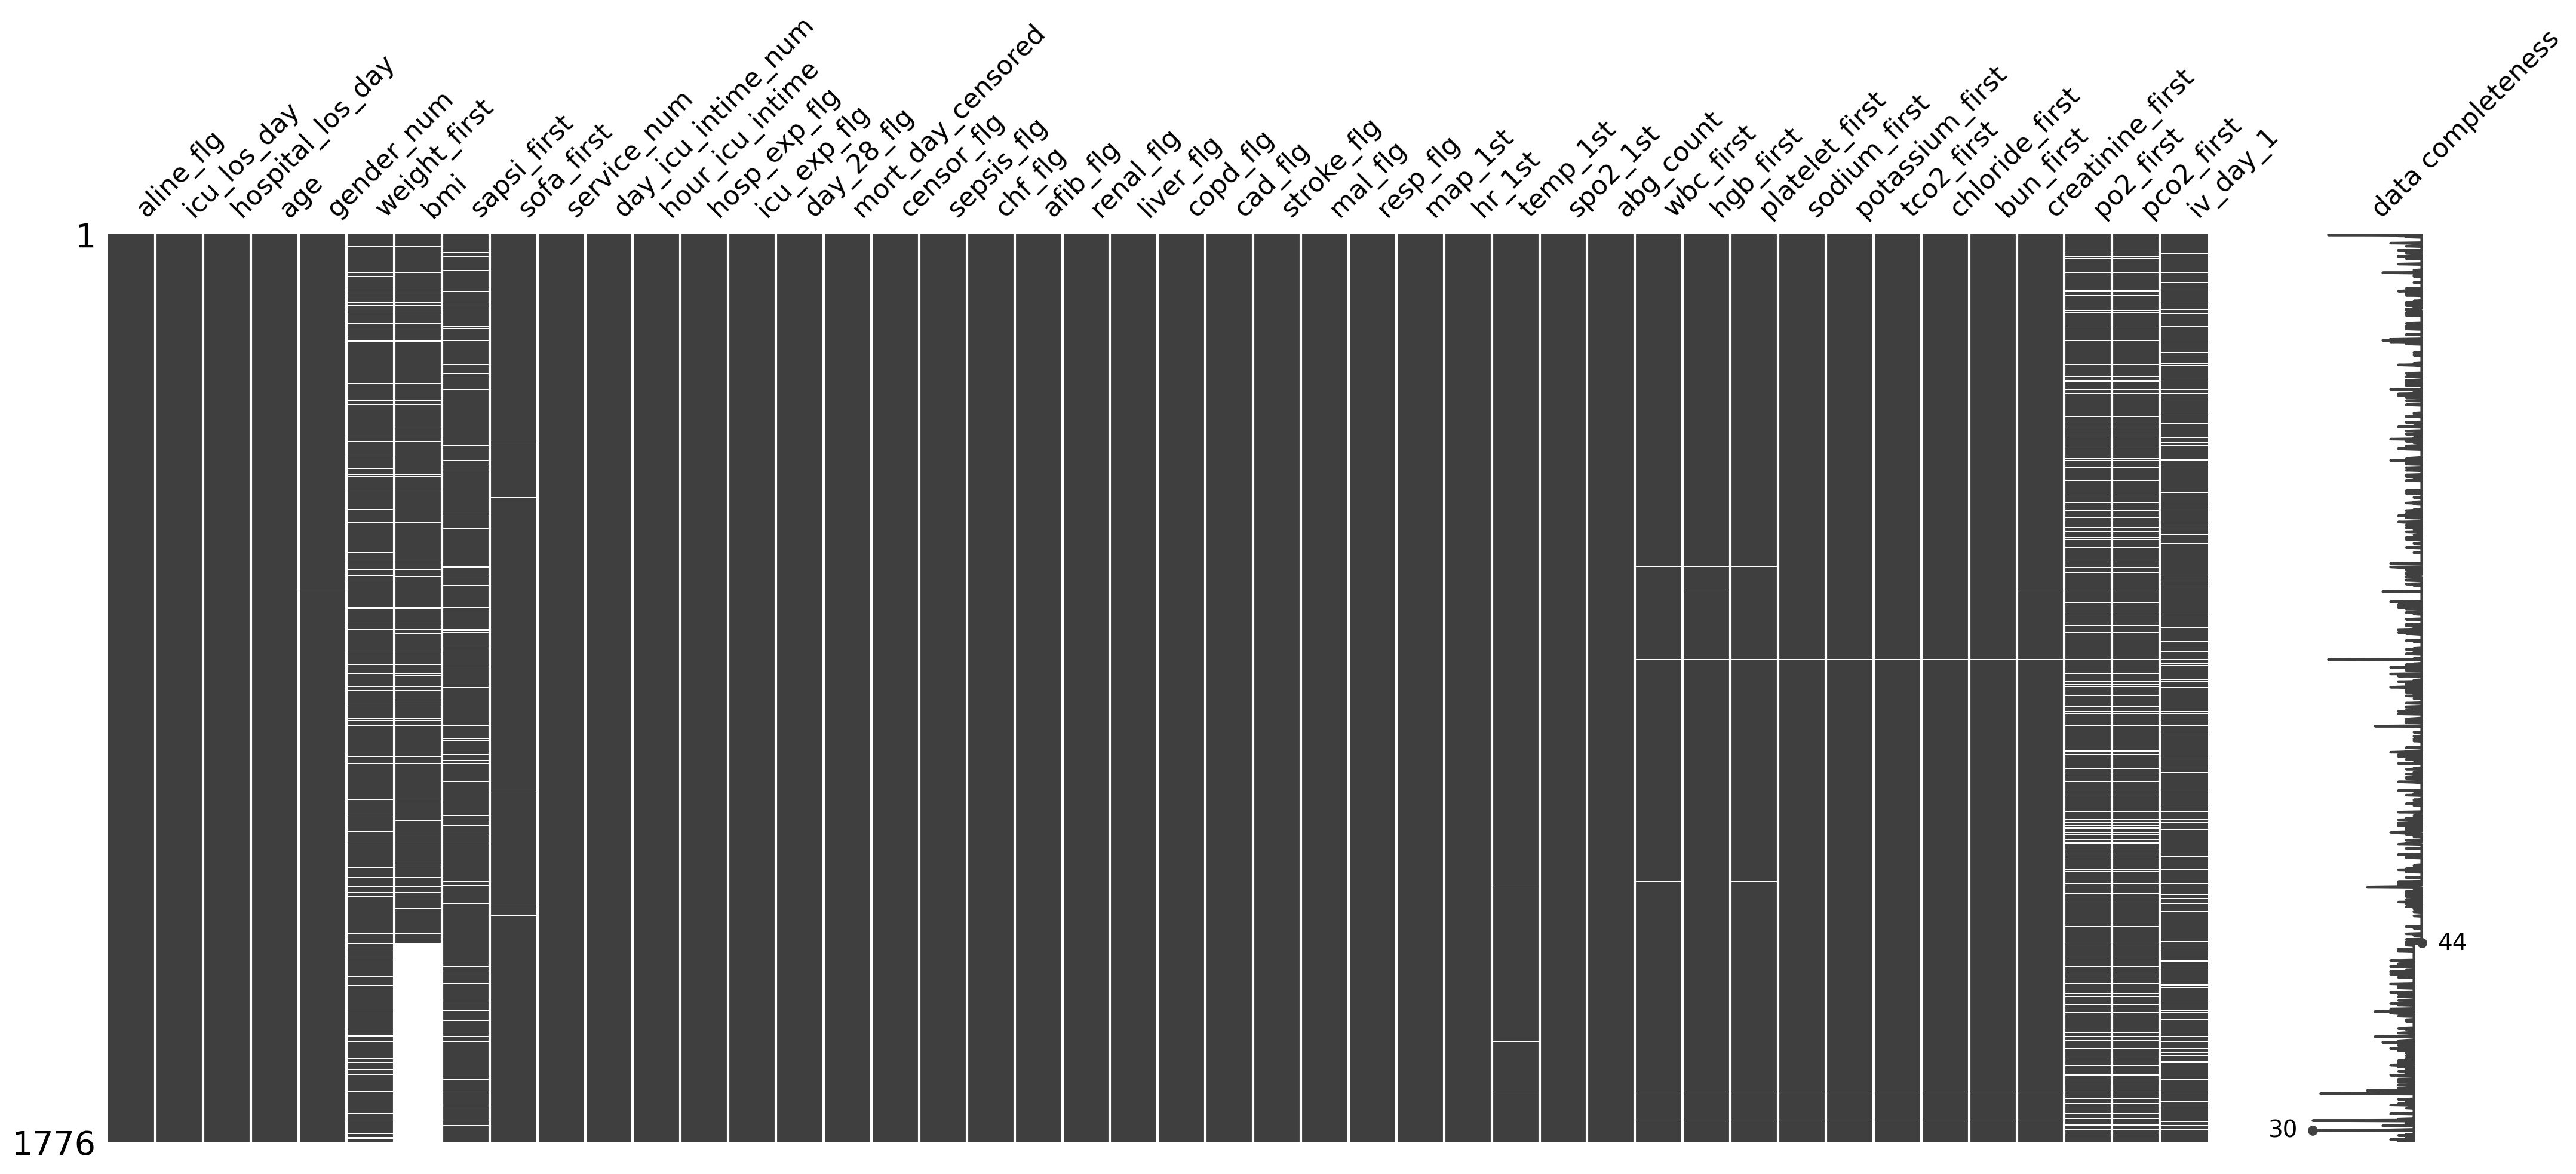

In [19]:
ep.pl.missing_values_matrix(edata)

We can also check which features have the highest percentage of missing values in both **obs** and **vars**.

In [20]:
edata.obs.loc[edata.obs["missing_values_pct"] == edata.obs["missing_values_pct"].max(), :]

,service_unit,day_icu_intime,missing_values_abs,missing_values_pct,entropy_of_missingness,unique_values_abs,unique_values_ratio
1732,SICU,Thursday,14,25.925926,0.825627,4,40.0
1751,MICU,Tuesday,14,25.925926,0.825627,4,40.0


In [21]:
edata.var.loc[edata.var["missing_values_pct"] == edata.var["missing_values_pct"].max(), :]

,feature_type,unencoded_var_names,encoding_mode,missing_values_abs,missing_values_pct,entropy_of_missingness,unique_values_abs,unique_values_ratio,coefficient_of_variation,is_constant,constant_variable_ratio,range_ratio,mean,median,standard_deviation,min,max,iqr_outliers
bmi,numeric,bmi,NaN,466,26.238739,0.830328,NaN,NaN,0.294924,0.0,2.272727,309.092904,27.827316,26.324846,8.20694,12.784877,98.797134,True


Overall, the percentage of missing values in all features is rather low, however, still some features are not complete.

Features with missing values can introduce a bias in the data, making the processing and analysis challenging. To prevent loss of information due to dropping of multiple features, we can fill up the missing values by performing an imputation. Here, we infer the missing values based on the exisitng part of the data. 

To perform this efficiently, we suggest to drop features if the percentage of missing values is very high (>60%). In our data, there is no need to drop any feature, since none exceeds more than 27% missing values (BMI, vars).

#### Missing data imputation

ehrapy offers many options to [impute](https://ehrapy.readthedocs.io/en/latest/usage/usage.html#imputation) missing values in an EHRData object.
Here, we use KNN imputation with 5 neighbors (`n_neighbors=5`, the default value). The KNN algorithm uses proximity to predict the missing values of a feature by finding the `k` closest neighbors to the missing value and then imputing the missing value based on the non-missing values in the neighborhood.

ehrapy offers two backends for the nearest neighbors search; `scikit-learn` and `faiss`. While `faiss` is faster for large datasets, `scikit-learn` is robustly reproducible across different machines.

We are interested to impute only numeric variables here.
The main reason for this is that for categorical variables, a very natural way of handling missingness instead of is a dedicated category for missing variables.

In [22]:
ep.pp.knn_impute(
    edata, backend="scikit-learn", n_neighbours=5, var_names=edata.var_names[edata.var["feature_type"] == "numeric"]
)

Output()

After recalcuating the QC metrices, we can check again the percentage of missing values.

In [23]:
ep.pp.qc_metrics(edata)

(      missing_values_abs  missing_values_pct  entropy_of_missingness  \
 0                      0                 0.0            3.466198e-09   
 1                      0                 0.0            3.466198e-09   
 2                      0                 0.0            3.466198e-09   
 3                      0                 0.0            3.466198e-09   
 4                      0                 0.0            3.466198e-09   
 ...                  ...                 ...                     ...   
 1771                   0                 0.0            3.466198e-09   
 1772                   0                 0.0            3.466198e-09   
 1773                   0                 0.0            3.466198e-09   
 1774                   0                 0.0            3.466198e-09   
 1775                   0                 0.0            3.466198e-09   
 
       unique_values_abs  unique_values_ratio  
 0                     4                 40.0  
 1                     4  

<Axes: >

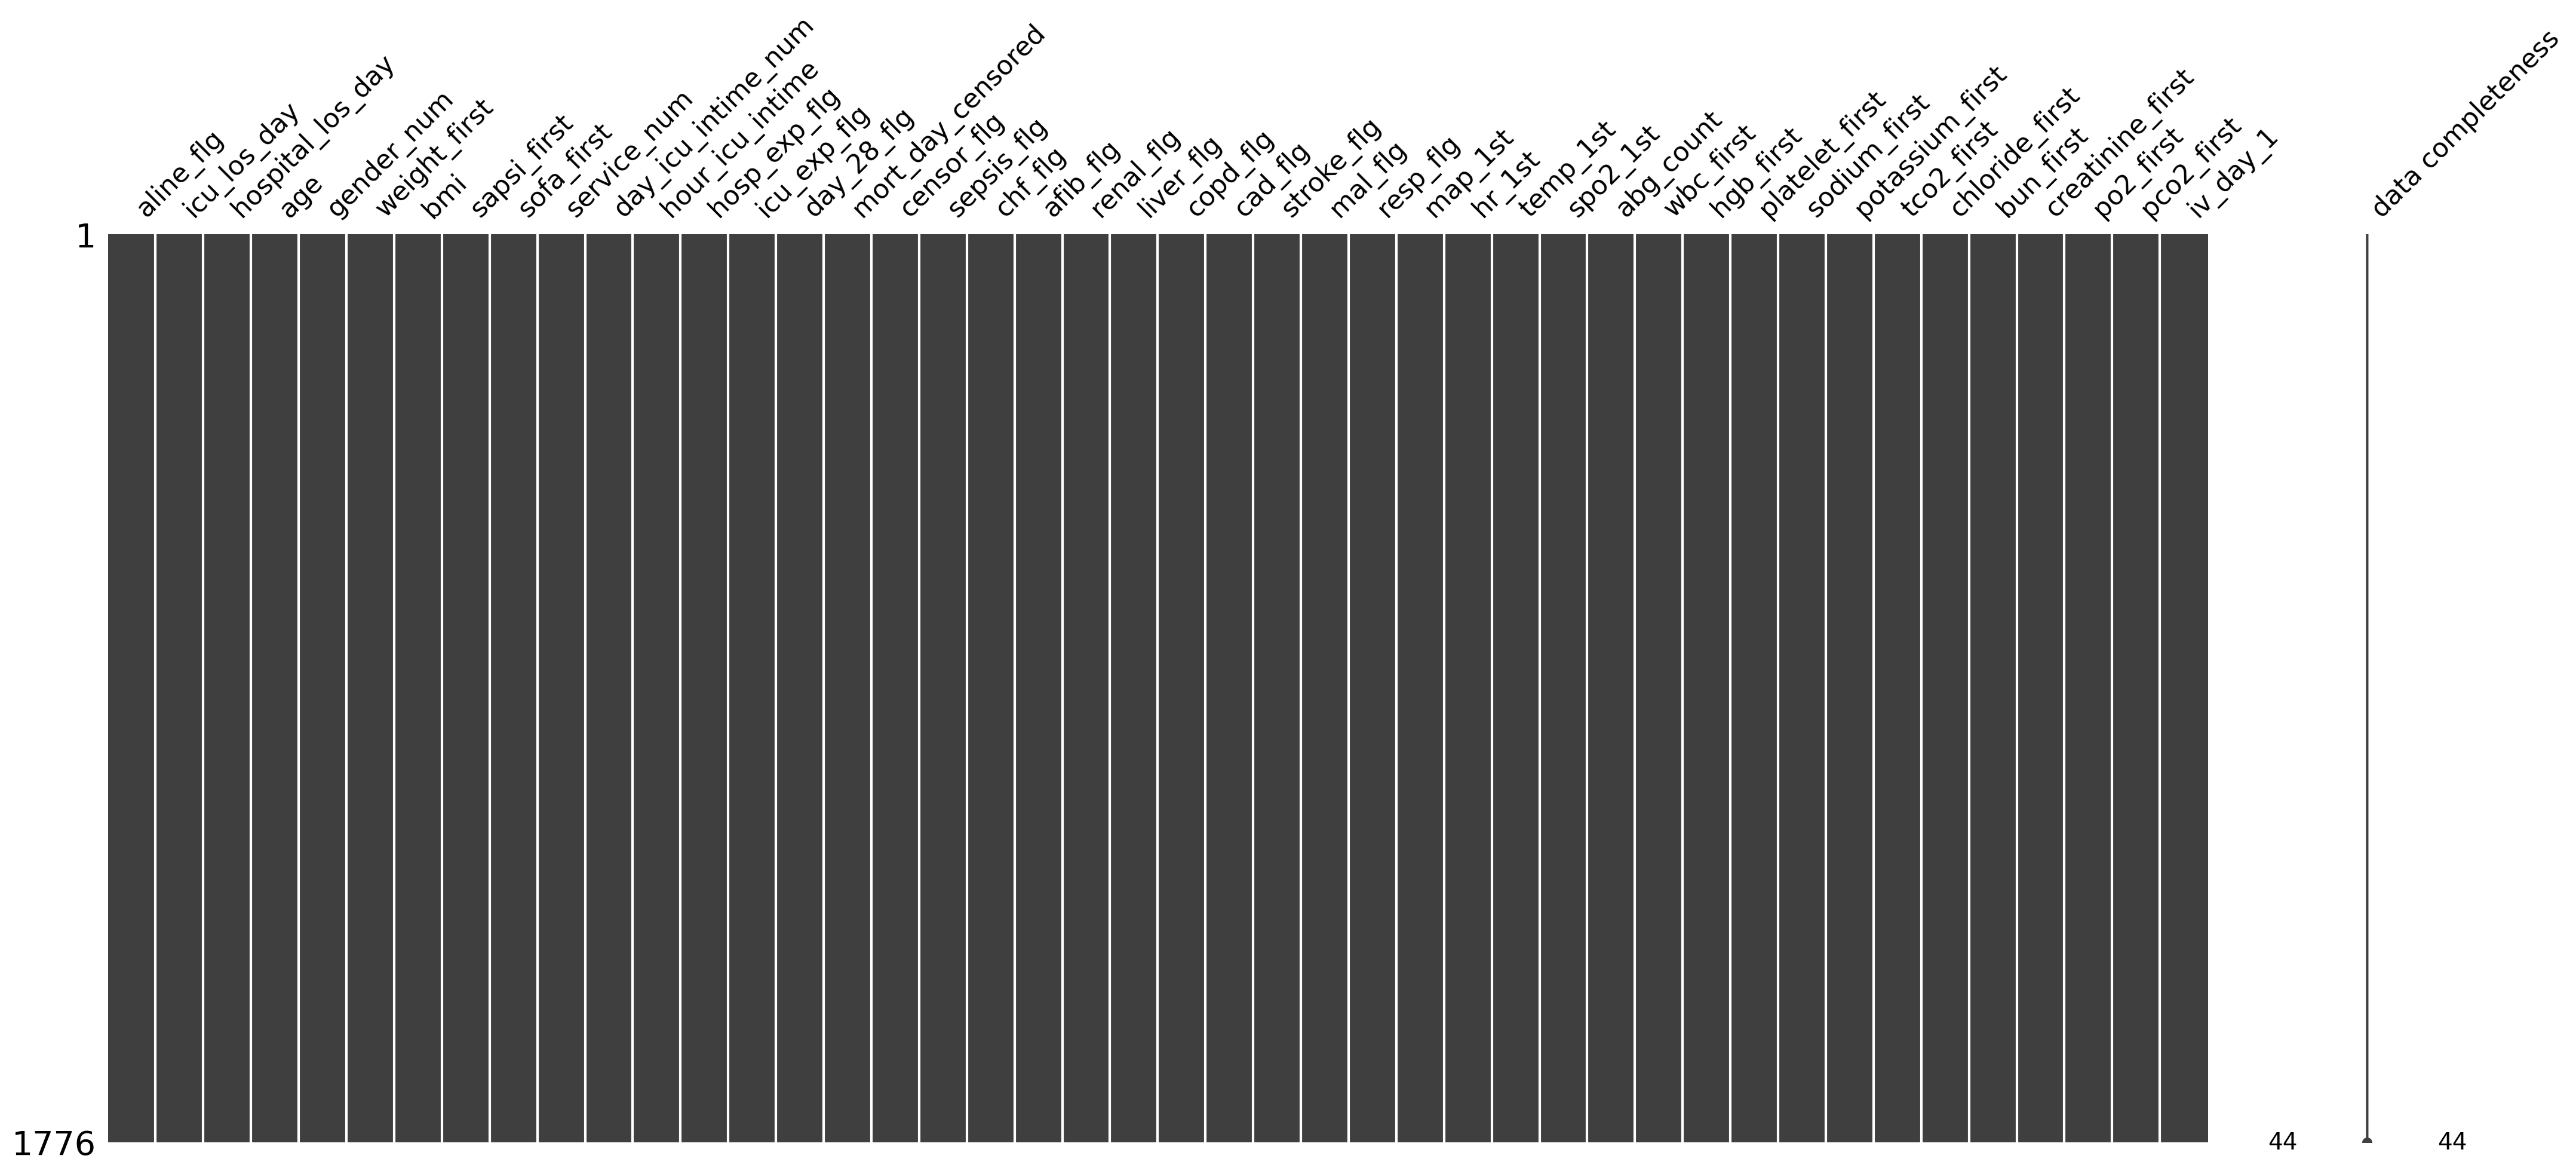

In [24]:
ep.pl.missing_values_matrix(edata)

#### Data distribution

Depending on the measurement and the unit of a measurement the value ranges of features may be huge.
Clusterings and differential comparisons especially may be greatly influenced by exceptionally big values. 

[Text(0.5, 1.0, 'maximum values')]

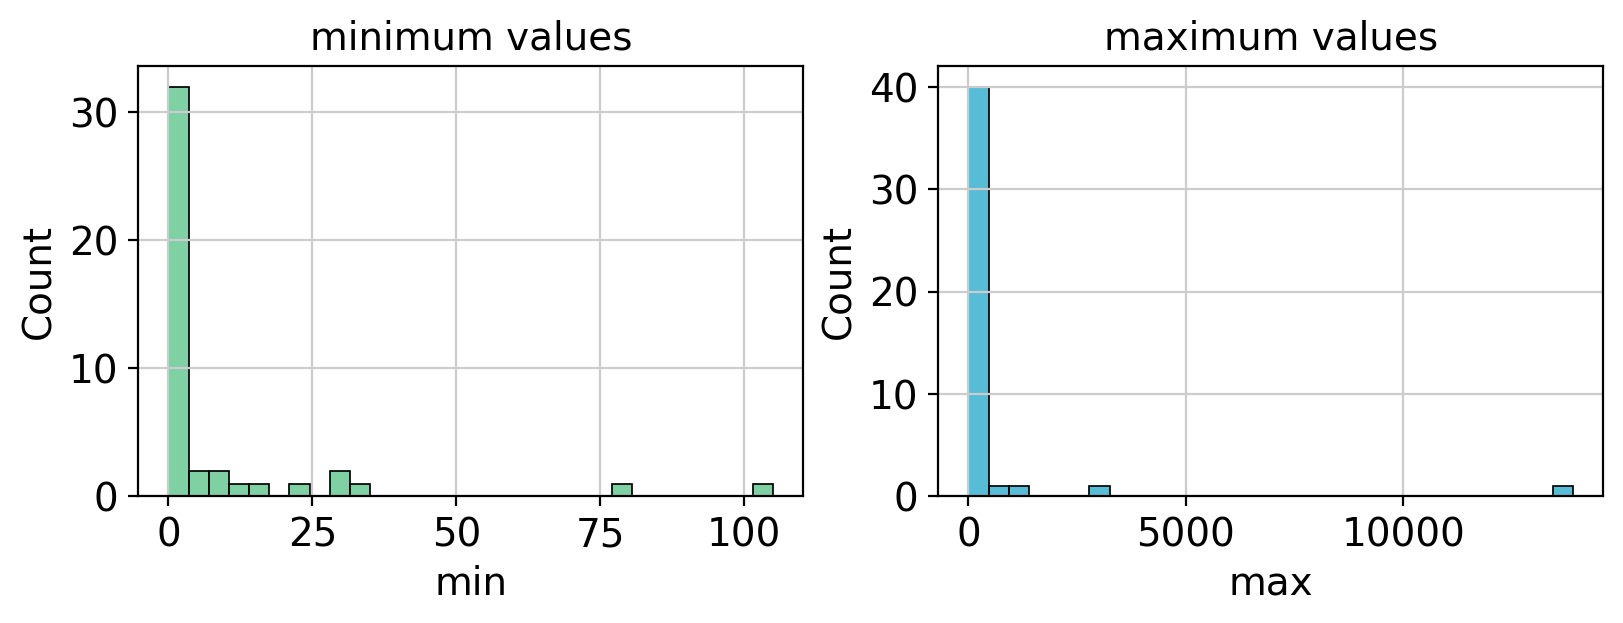

In [25]:
axd = plt.figure(constrained_layout=True, figsize=(8, 3), dpi=100).subplot_mosaic(
    """
    AB
    """
)

sns.histplot(edata.var["min"], ax=axd["A"], bins=30, color="#54C285").set(title="minimum values")
sns.histplot(edata.var["max"], ax=axd["B"], bins=30, color="#1FA6C9").set(title="maximum values")

Moreover, features which have a very high coefficient of variation can strongly influence dimensionality reduction. However, since the coefficient of variation performs weak with features that have small means, we only select those which have no small mean. 

In [26]:
edata.var["coefficient.variation"] = (edata.var["standard_deviation"] / edata.var["mean"]) * 100

In [27]:
edata.var.loc[(edata.var["coefficient.variation"] > 50) & (edata.var["mean"] > 50),]

,feature_type,unencoded_var_names,encoding_mode,missing_values_abs,missing_values_pct,entropy_of_missingness,unique_values_abs,unique_values_ratio,coefficient_of_variation,is_constant,constant_variable_ratio,range_ratio,mean,median,standard_deviation,min,max,iqr_outliers,coefficient.variation
mort_day_censored,numeric,mort_day_censored,NaN,0,0.0,3.466198e-09,NaN,NaN,0.655993,0.0,2.272727,503.651288,614.329825,731.0,402.996046,0.0,3094.080078,True,65.599297
po2_first,numeric,po2_first,NaN,0,0.0,3.466198e-09,NaN,NaN,0.604144,0.0,2.272727,265.742288,230.298311,204.0,139.133431,22.0,634.000000,True,60.414439
iv_day_1,numeric,iv_day_1,NaN,0,0.0,3.466198e-09,NaN,NaN,1.003303,0.0,2.272727,862.094683,1613.511866,1150.0,1618.841925,0.0,13910.000000,True,100.330339


The standard deviations and coefficients of variation of the features **iv_day_1** (input fluids by IV on day 1 in mL) and **po2_first** (first PaO_2 in mmHg) are very high with strong spread between minimum and maximum values. These features require normalization. 

### Normalization

ehrapy offers several options to [normalize](https://ehrapy.readthedocs.io/en/latest/usage/usage.html#normalization) data. While it is possible to normalize all numerical values at once with the same normalization function, normalizing only the features with high spread, here **iv_day_1** and **po2_first**, can be sufficient.
Log normalization with an offset of 1 to add pseudocounts seems appropriate.

Note: When features with negative values should be normalized you have to use the *pp.offset_negative_values()* function prior normalization.

In [28]:
ep.pp.log_norm(edata, vars=["iv_day_1", "po2_first"], offset=1)

after normalization we can calculate the QC metrices again and check the distribution. 

In [29]:
ep.pp.qc_metrics(edata)

(      missing_values_abs  missing_values_pct  entropy_of_missingness  \
 0                      0                 0.0            3.466198e-09   
 1                      0                 0.0            3.466198e-09   
 2                      0                 0.0            3.466198e-09   
 3                      0                 0.0            3.466198e-09   
 4                      0                 0.0            3.466198e-09   
 ...                  ...                 ...                     ...   
 1771                   0                 0.0            3.466198e-09   
 1772                   0                 0.0            3.466198e-09   
 1773                   0                 0.0            3.466198e-09   
 1774                   0                 0.0            3.466198e-09   
 1775                   0                 0.0            3.466198e-09   
 
       unique_values_abs  unique_values_ratio  
 0                     4                 40.0  
 1                     4  

In [30]:
edata.var["coefficient.variation"] = (edata.var["standard_deviation"] / edata.var["mean"]) * 100
edata.var.loc[(edata.var["coefficient.variation"] > 50) & (edata.var["mean"] > 50),]

,feature_type,unencoded_var_names,encoding_mode,missing_values_abs,missing_values_pct,entropy_of_missingness,unique_values_abs,unique_values_ratio,coefficient_of_variation,is_constant,constant_variable_ratio,range_ratio,mean,median,standard_deviation,min,max,iqr_outliers,coefficient.variation
mort_day_censored,numeric,mort_day_censored,NaN,0,0.0,3.466198e-09,NaN,NaN,0.655993,0.0,2.272727,503.651288,614.329825,731.0,402.996046,0.0,3094.080078,True,65.599297


The strong spread of **iv_day_1** and **po2_first** was succesfully removed. Now that we normalized the influence of these features, we can continue with dimensionality reduction. 

Dimensionality reduction reduces the number of features (dimensions) by projecting the data to a lower dimensional latent space retaining as much information as possible. This is very useful for high dimensional data, since it reduces complexity and facilitates visualization.

### Dimensionality reduction

#### Principle Component Analysis (PCA)

As a next step, we reduce the dimensionality of the dataset with [principal component analysis (PCA)](https://en.wikipedia.org/wiki/Principal_component_analysis).
We can also visualize the principal components with ehrapy using the `components` argument.

`scanpy`, which ehrapy uses under the hood, provides many options for computing a PCA. The option `randomized` with a random state is particularly reproducible across different machines. However, different BLAS/LAPACK backends used on different machines have slight differences in SVD. For exact reproducibility, working on in a containerized environment is essential.

In [31]:
ep.pp.pca(edata, svd_solver="randomized", random_state=42)

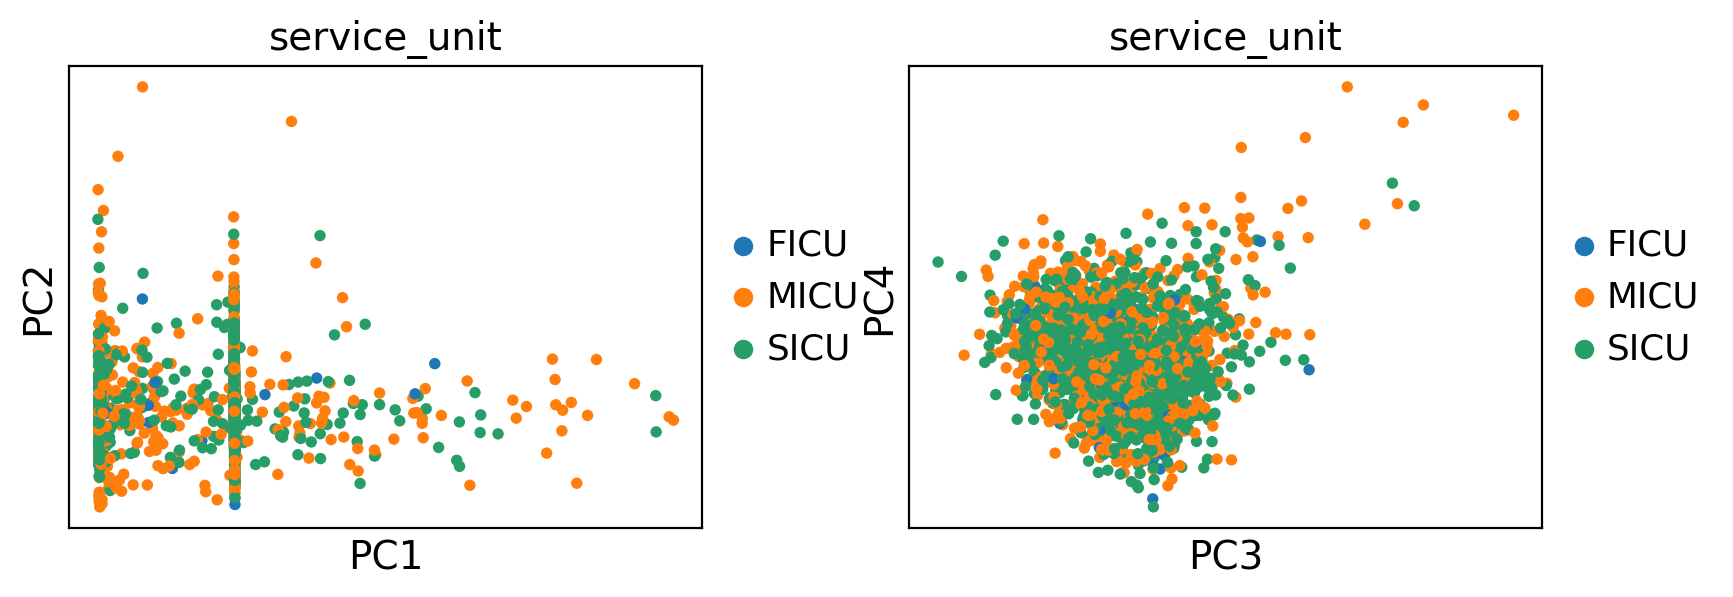

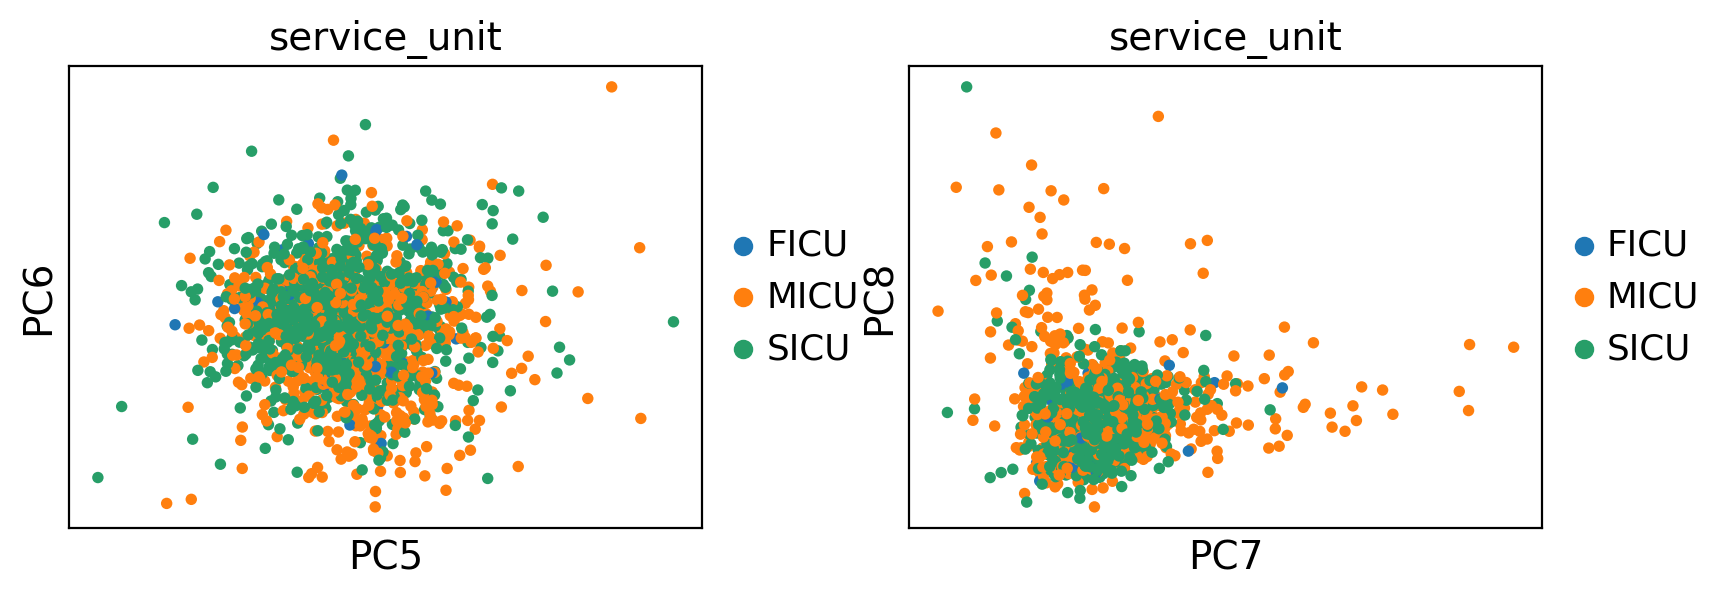

In [32]:
ep.pl.pca(edata, color="service_unit", components=["1,2", "3,4"])
ep.pl.pca(edata, color="service_unit", components=["5,6", "7,8"])

To inspect certain PCs further, we can inspect the PC dimensionality loadings which highlight the features that contribute strongest to the selected PC.

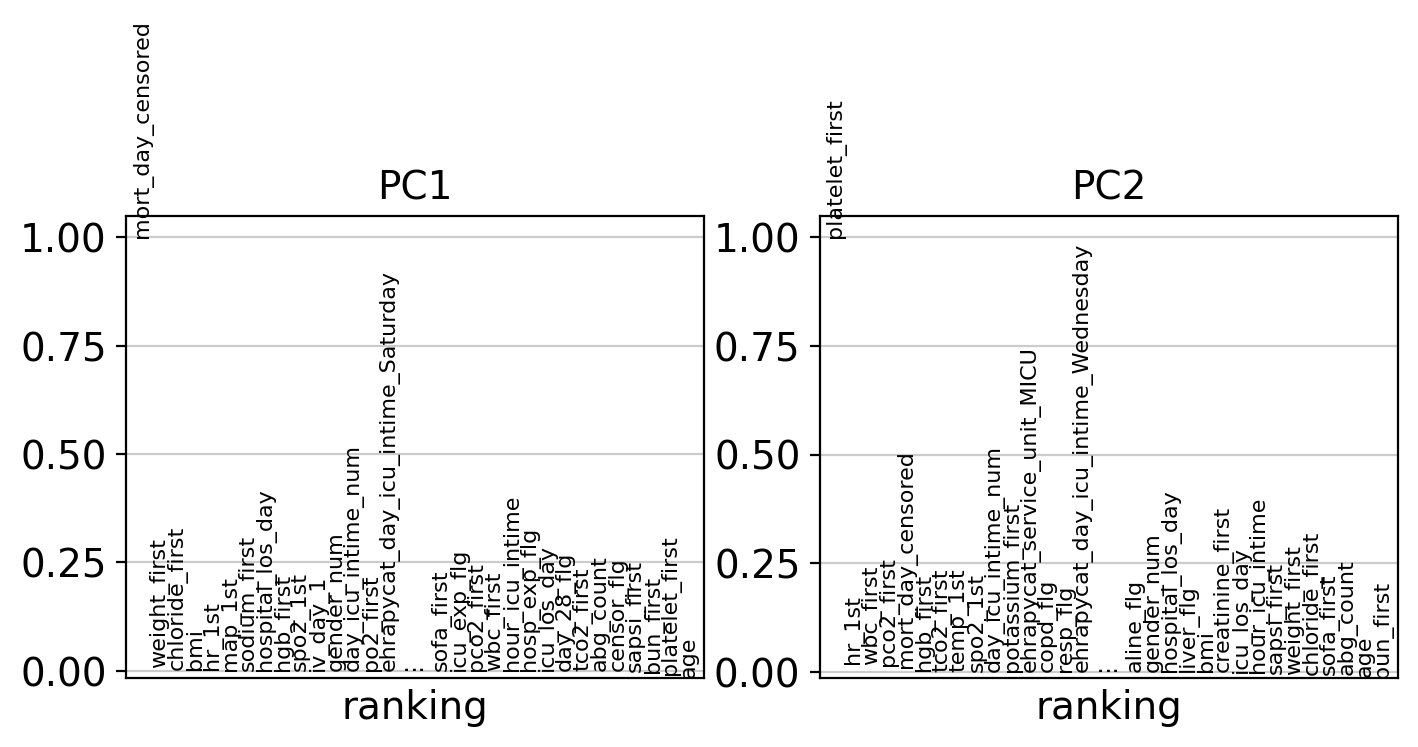

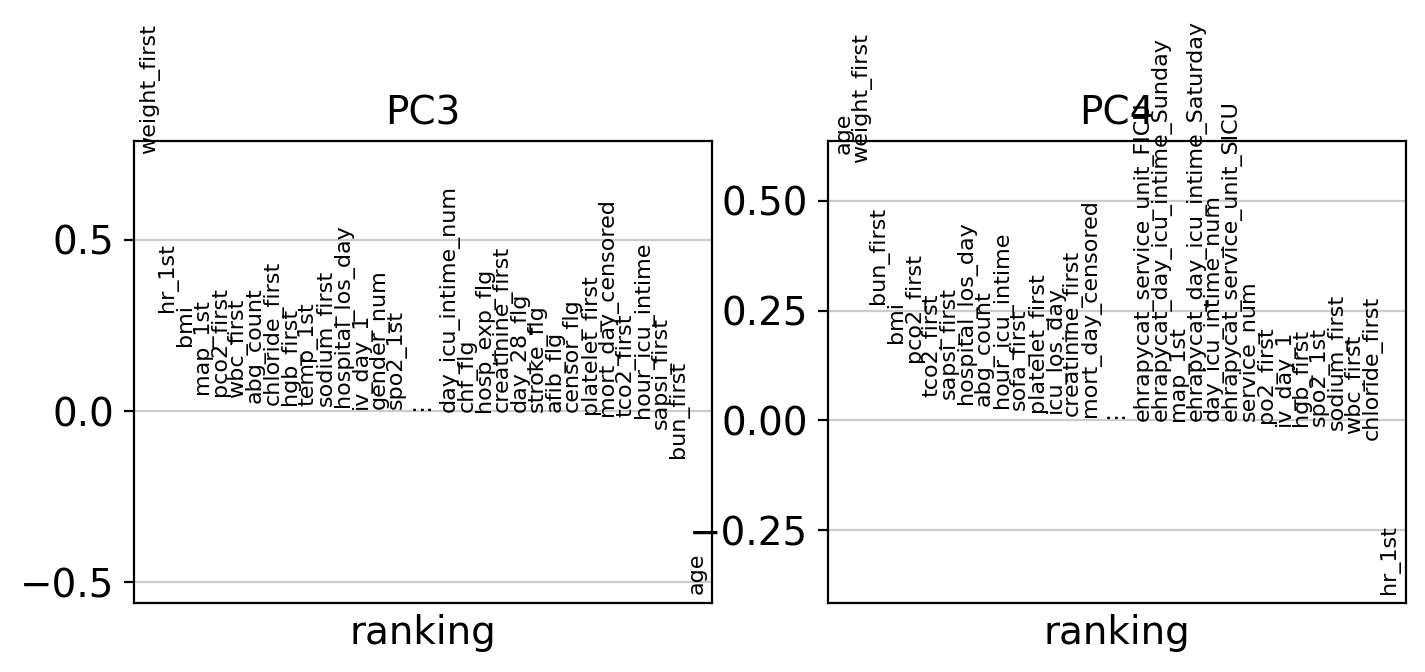

In [33]:
ep.pl.pca_loadings(edata, components="1, 2")
ep.pl.pca_loadings(edata, components="3, 4")

#### Uniform Manifold Approximation and Projection (UMAP) 

The reduced representation can then be used as input for the neighbors graph calculation which serves as the input for advanced embeddings and visualizations like [Uniform Manifold Approximation and Projection (UMAP) ](https://umap-learn.readthedocs.io/en/latest/)

ehrapy provides multiple implementations for neighborhood search. By setting `transformer="sklearn"`, brute-force, but robustly reproducible implementation across machines is available. Faster options for the `transformers` argument are available, too.

In [34]:
ep.pp.neighbors(edata, transformer="sklearn", n_pcs=10)

In [35]:
ep.tl.umap(edata)

### Checking for Batch effects

Before exploring the data further, we need to see if we have a batch effect. A batch effect can e.g. arise from different collection units or collection days. To check if our data contains a batch for those feautures, we visualize the `service_unit` and the `day_icu_intime`.


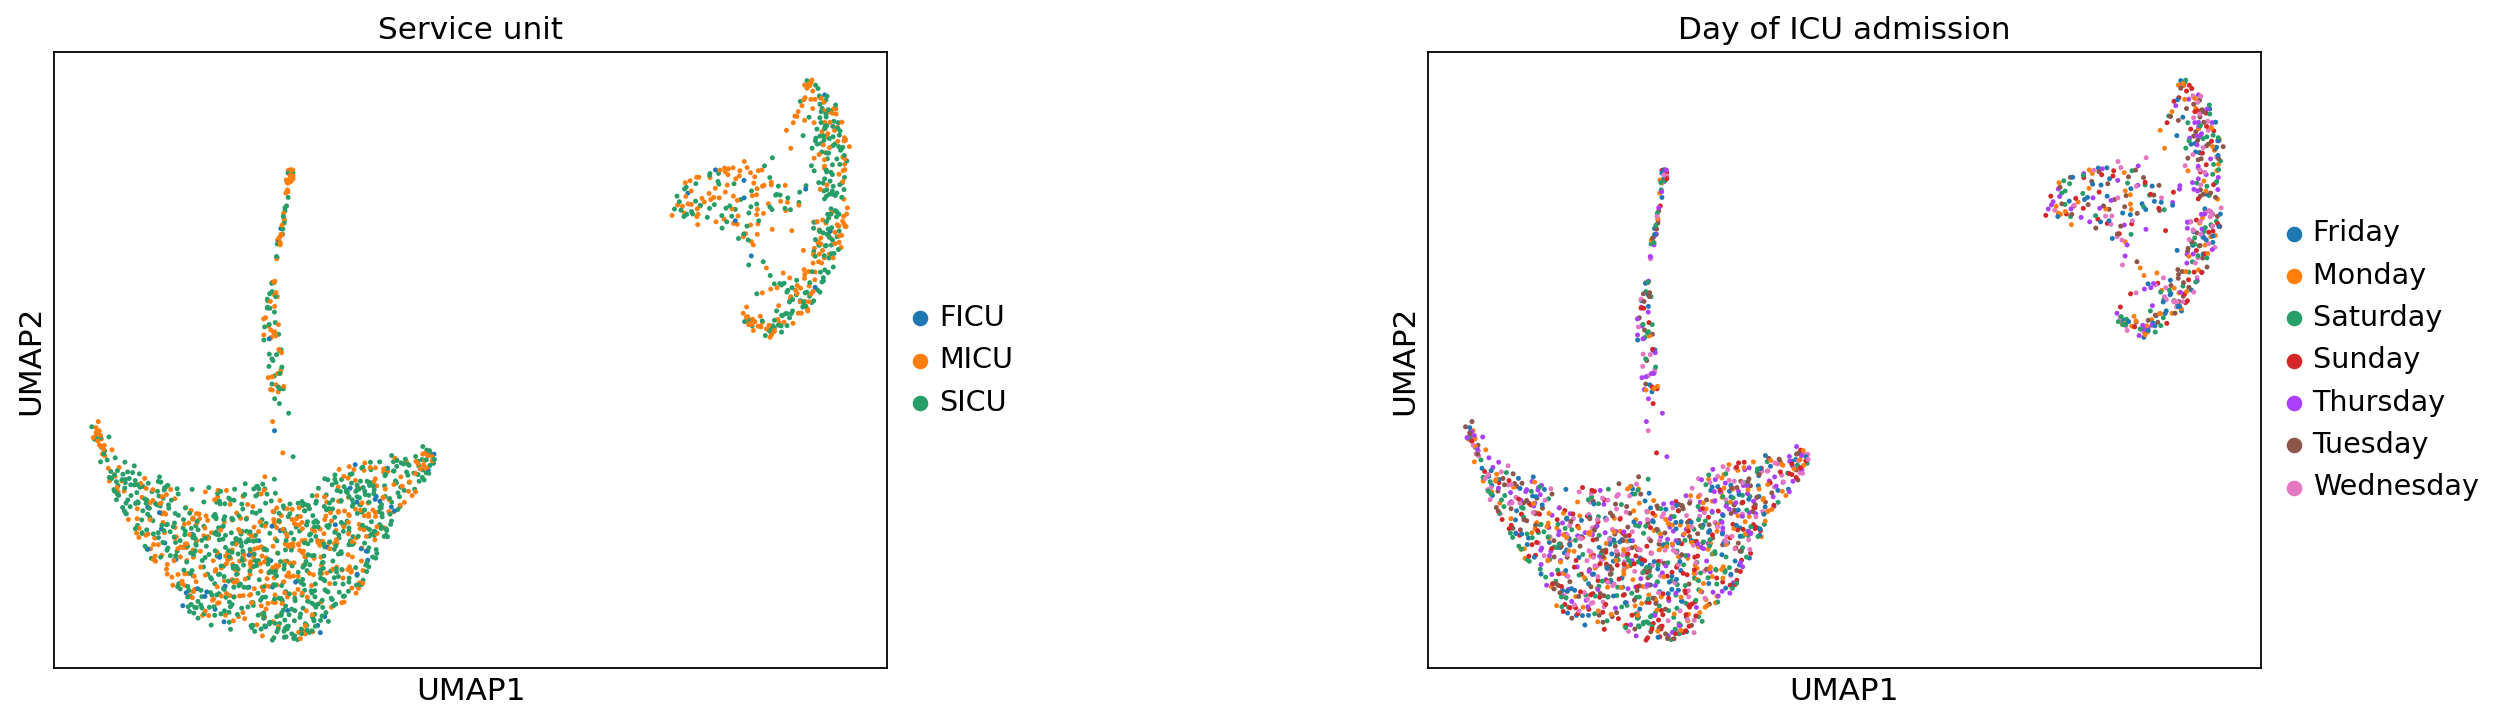

In [36]:
plt.rcParams["figure.figsize"] = (6, 5)
ep.pl.umap(
    edata,
    color=[
        "service_unit",
        "day_icu_intime",
    ],
    wspace=0.5,
    size=20,
    title=["Service unit", "Day of ICU admission"],
)

The embeddings suggest that there's no strong effect by the aforementioned potential confounders.

### Selected features on UMAP

Now we can also highlight other relevant features on the UMAP. Interesting features could be demographics, hospital statistics and lab parameters.

#### Demographics

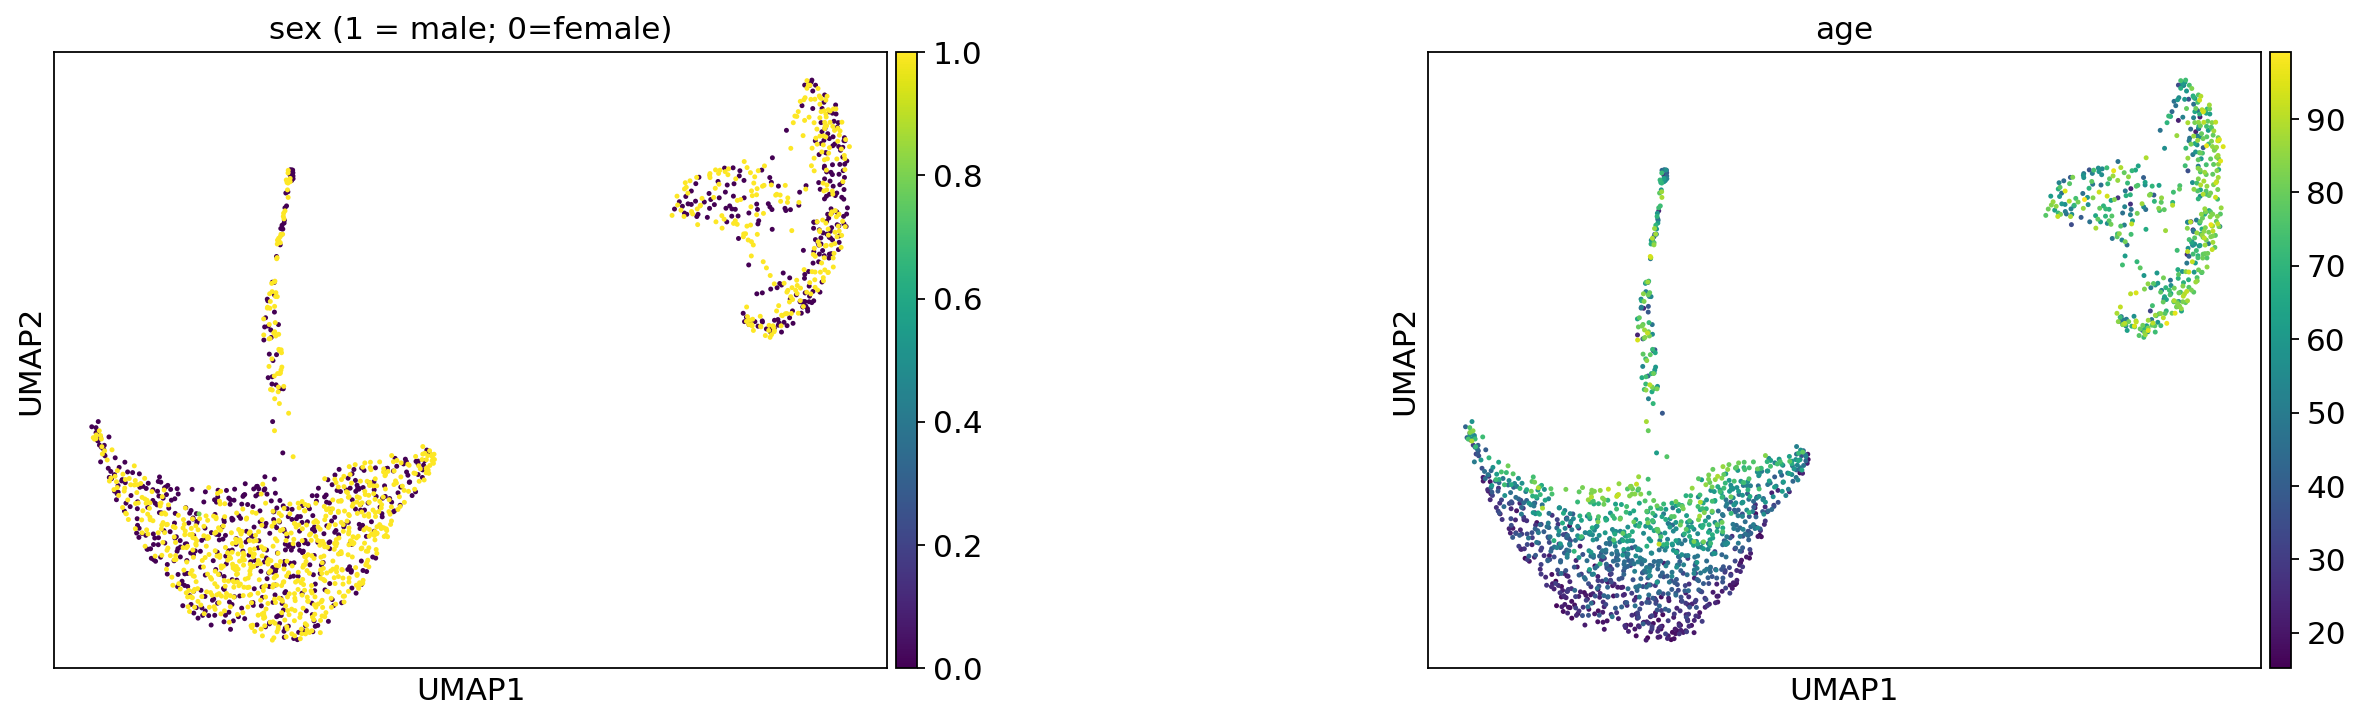

In [37]:
ep.pl.umap(
    edata,
    color=["gender_num", "age"],
    wspace=0.5,
    size=20,
    title=["sex (1 = male; 0=female)", "age"],
)

#### Hospital statistics

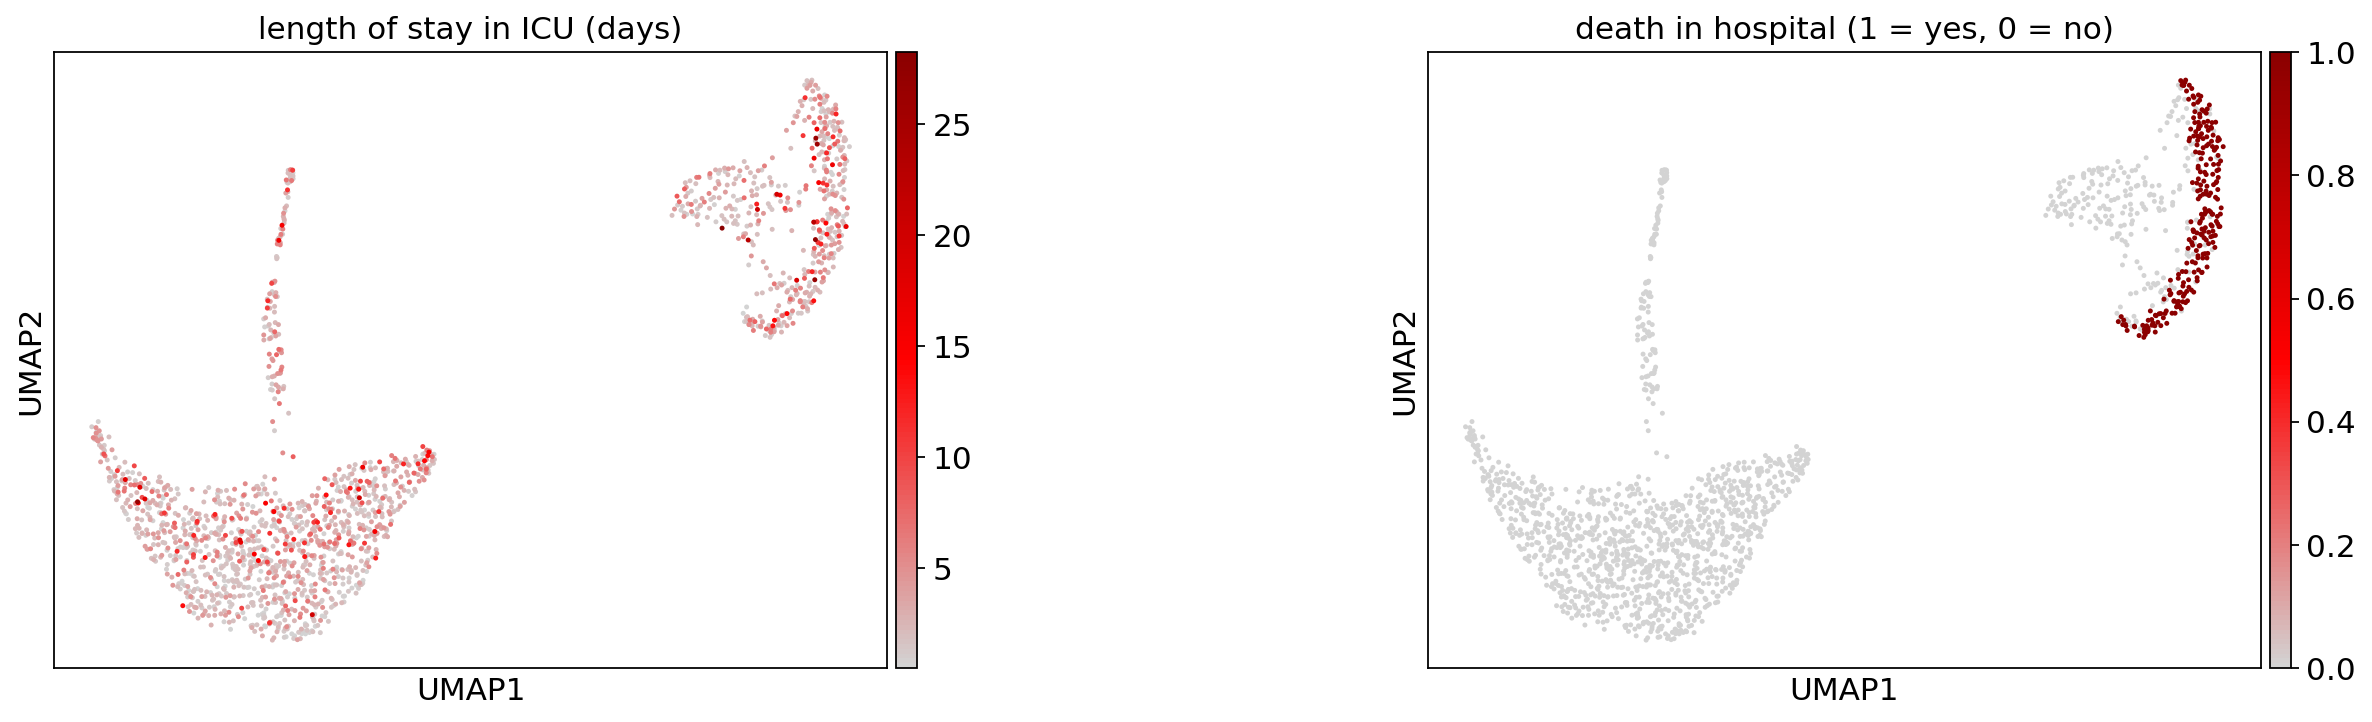

In [38]:
ep.pl.umap(
    edata,
    color=["icu_los_day", "hosp_exp_flg"],
    wspace=0.5,
    size=20,
    cmap=ep.pl.Colormaps.grey_red.value,
    title=["length of stay in ICU (days)", "death in hospital (1 = yes, 0 = no)"],
)

#### Comorbidities

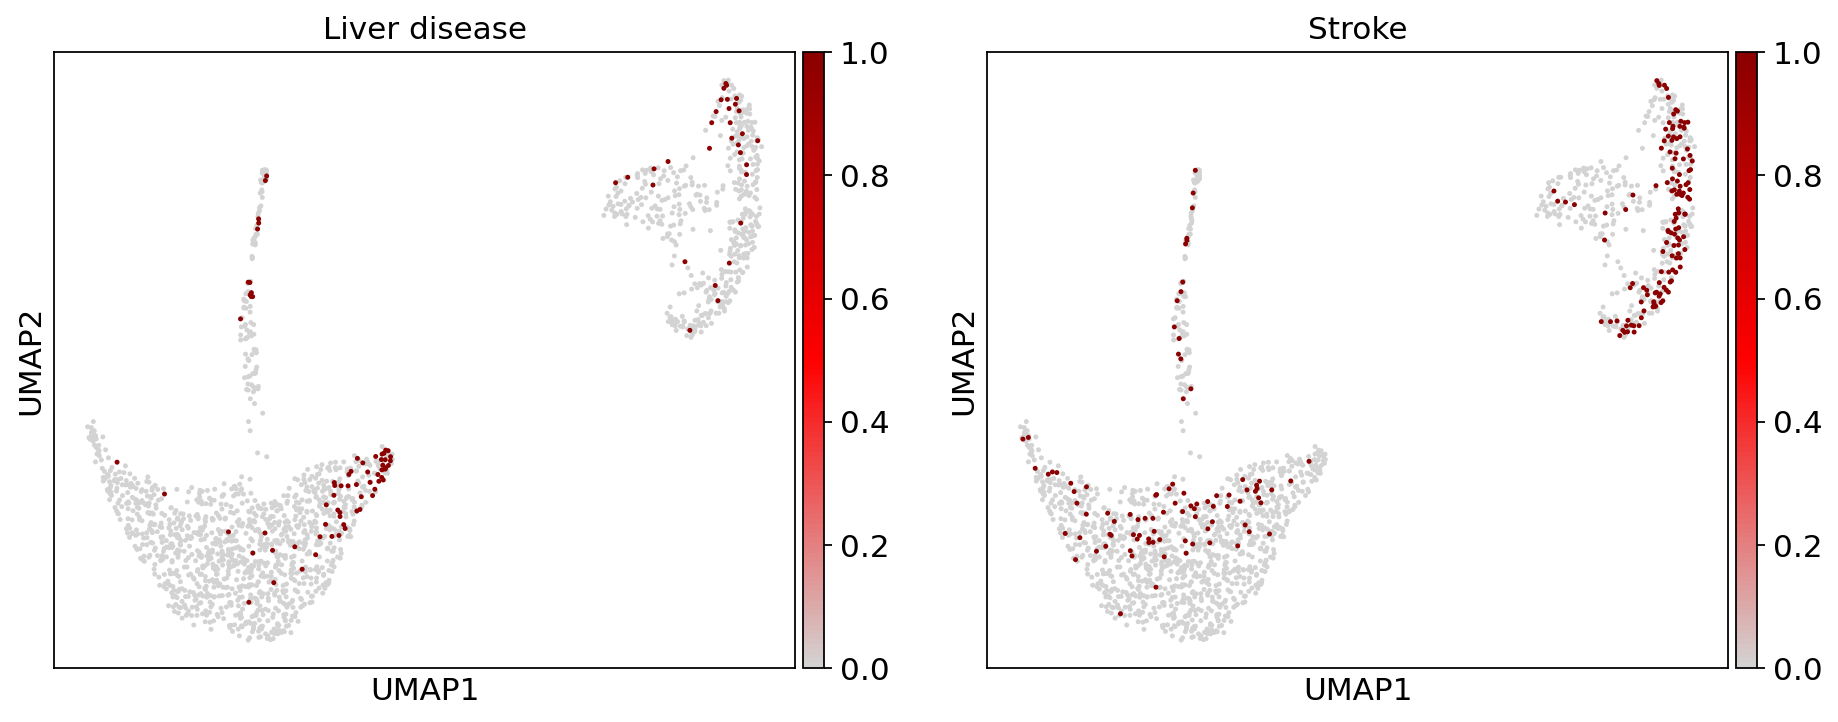

In [39]:
ep.pl.umap(
    edata,
    color=["liver_flg", "stroke_flg"],
    cmap=ep.pl.Colormaps.grey_red.value,
    title=["Liver disease", "Stroke"],
    ncols=2,
    size=20,
)

#### Lab parameters

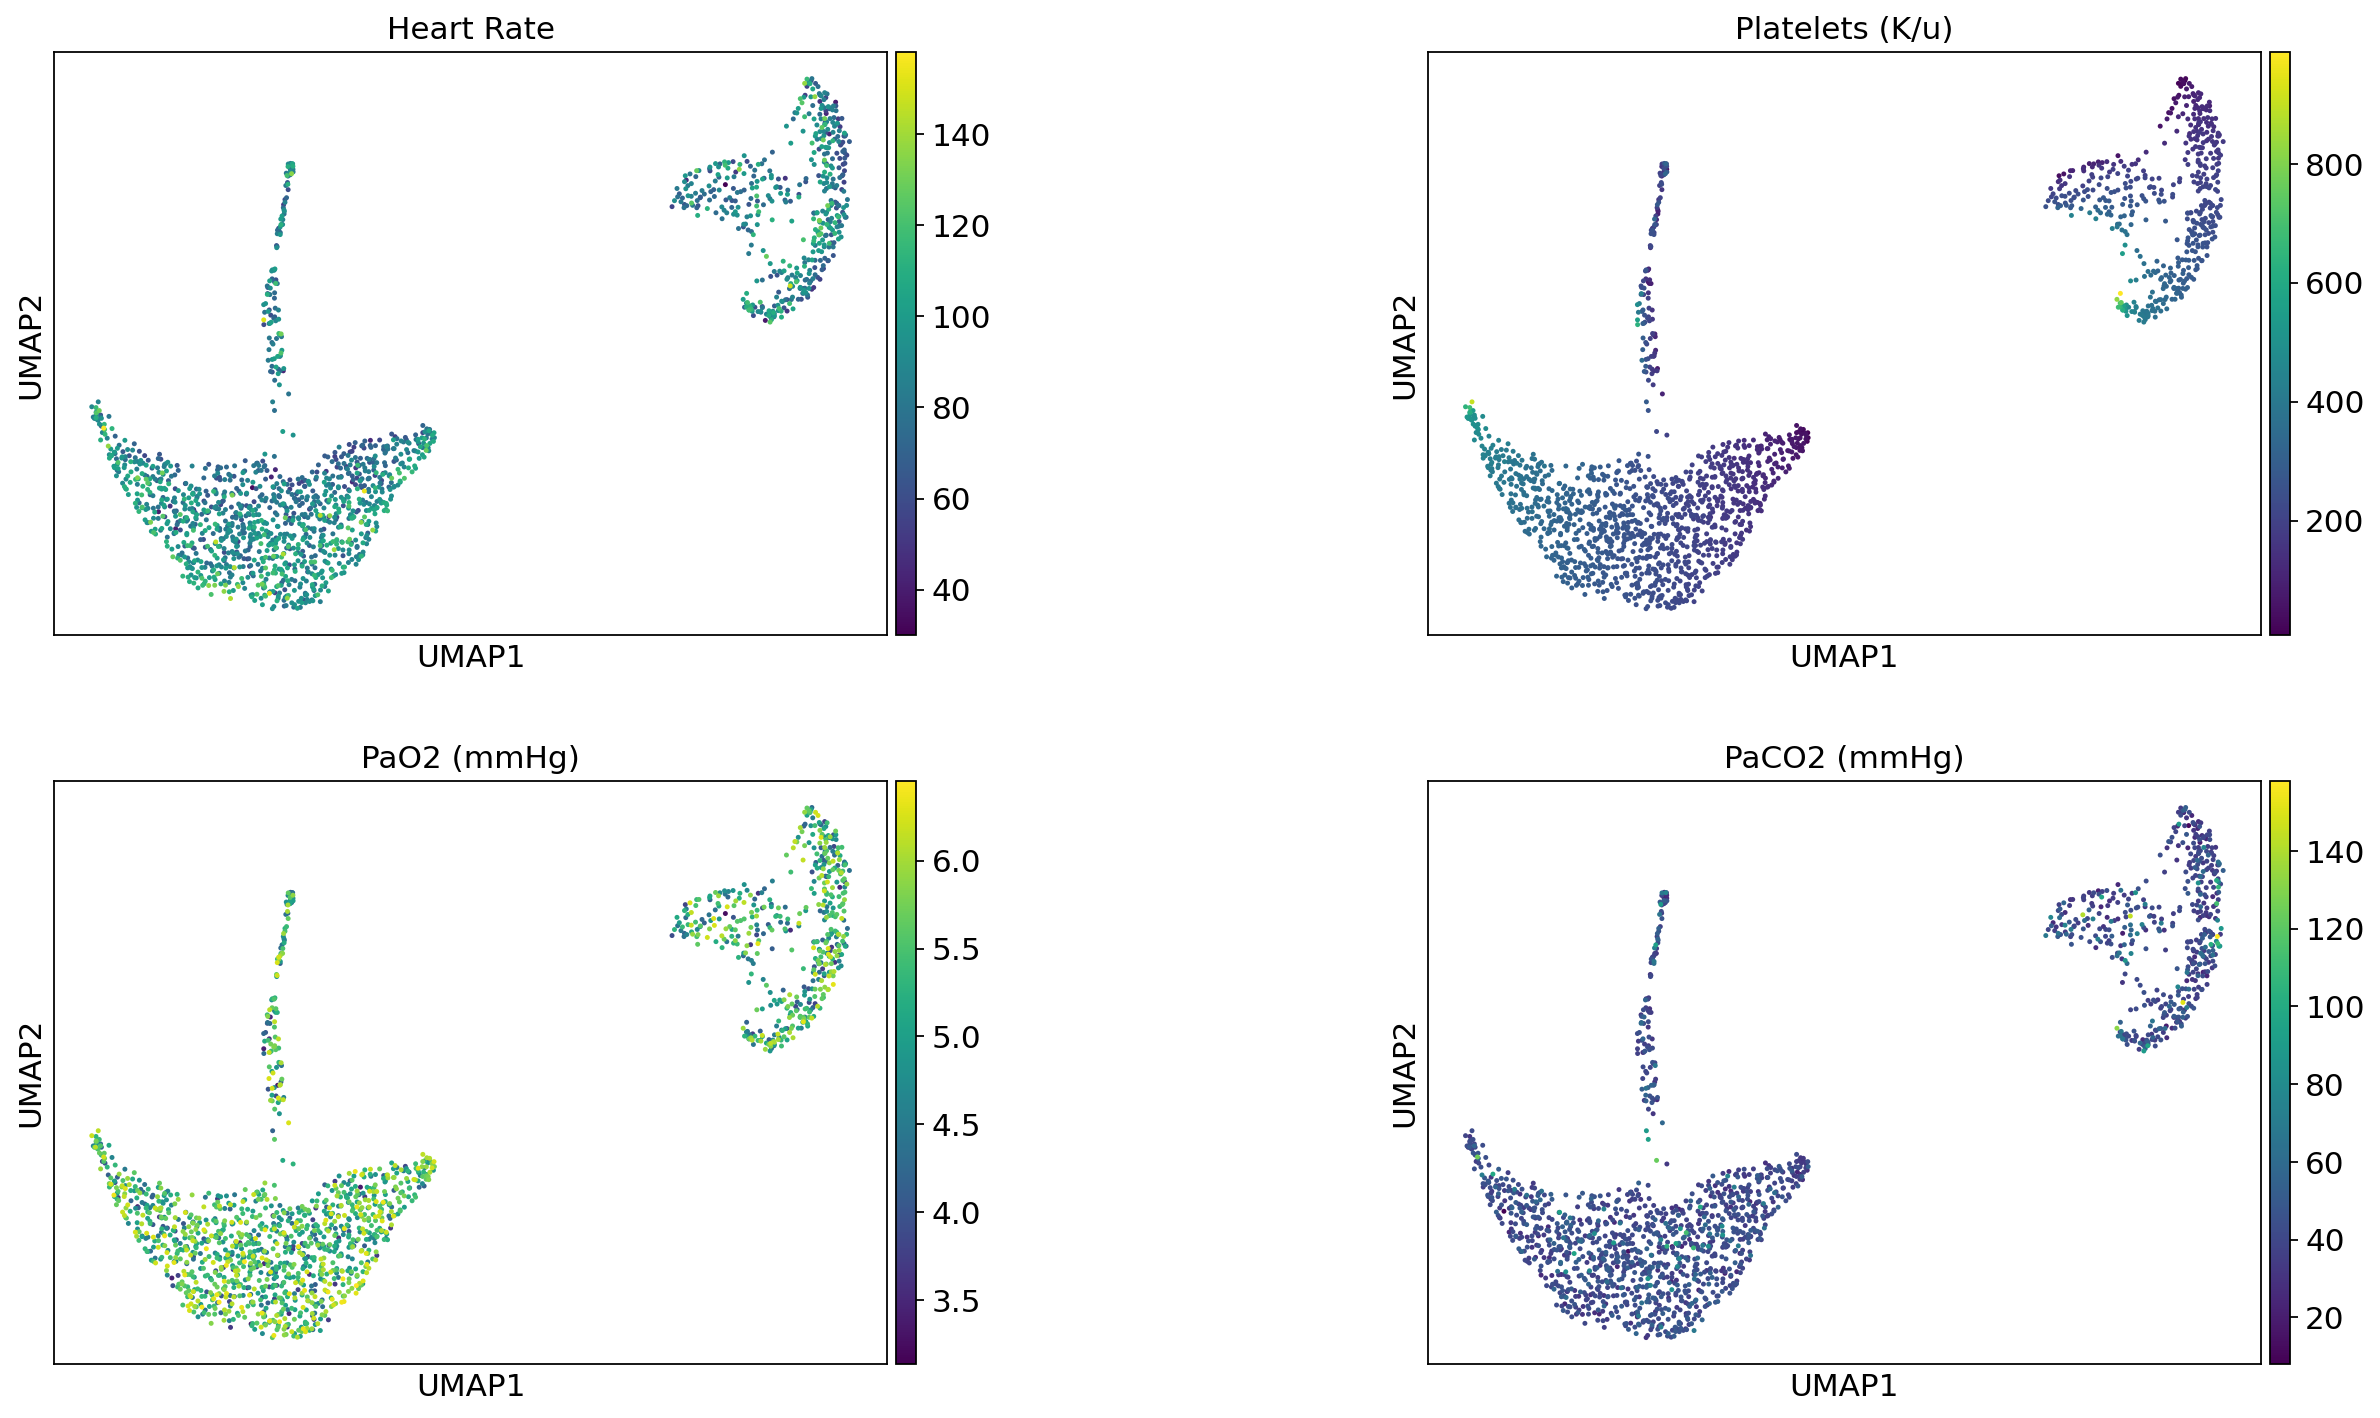

In [40]:
ep.pl.umap(
    edata,
    color=["hr_1st", "platelet_first", "po2_first", "pco2_first"],
    wspace=0.5,
    ncols=2,
    size=20,
    title=["Heart Rate", "Platelets (K/u)", "PaO2 (mmHg)", "PaCO2 (mmHg)"],
)

### Cluster analysis

To make more sense of the embedding it is often times useful to determine clusters through e.g. community detection as implemented in the [Leiden algorithm](https://www.nature.com/articles/s41598-019-41695-z). Moreover, clustering allows for unbiased detection of features that are changed between clusters and therefore intersting for us.  

#### Cluster identification

The implementation in ehrapy allows for the setting of a resolution which determines the number of found clusters. It is often times useful to play around with the parameter.

In [41]:
ep.tl.leiden(edata, resolution=0.3, key_added="leiden_0_3")

The leiden algorithm added a key to **obs** (`leiden_0_3`) that stores the clusters. These can subsequently be visualized in the UMAP embedding.

In [42]:
edata.obs.head(4)

,service_unit,day_icu_intime,missing_values_abs,missing_values_pct,entropy_of_missingness,unique_values_abs,unique_values_ratio,leiden_0_3
0,SICU,Friday,0,0.0,3.466198e-09,4,40.0,0
1,MICU,Saturday,0,0.0,3.466198e-09,4,40.0,1
2,MICU,Friday,0,0.0,3.466198e-09,4,40.0,1
3,SICU,Saturday,0,0.0,3.466198e-09,4,40.0,0


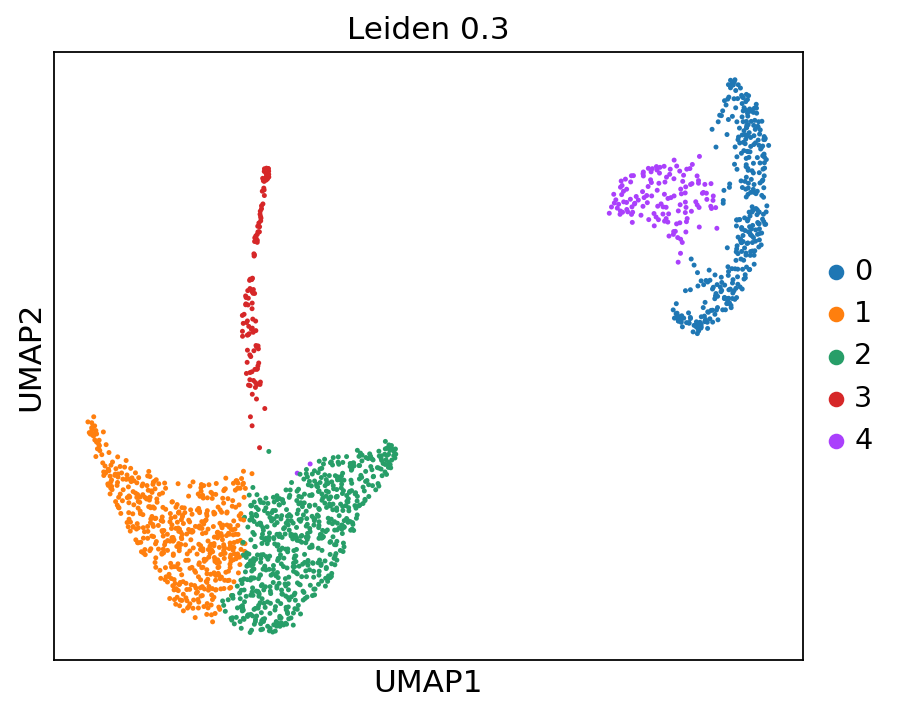

In [43]:
ep.pl.umap(edata, color=["leiden_0_3"], title="Leiden 0.3", size=20)

Next, we can explore certain features which are special for certrain clusters and could therefore be used for annotation.

#### Cluster features

In [44]:
ep.tl.rank_features_groups(edata, groupby="leiden_0_3")

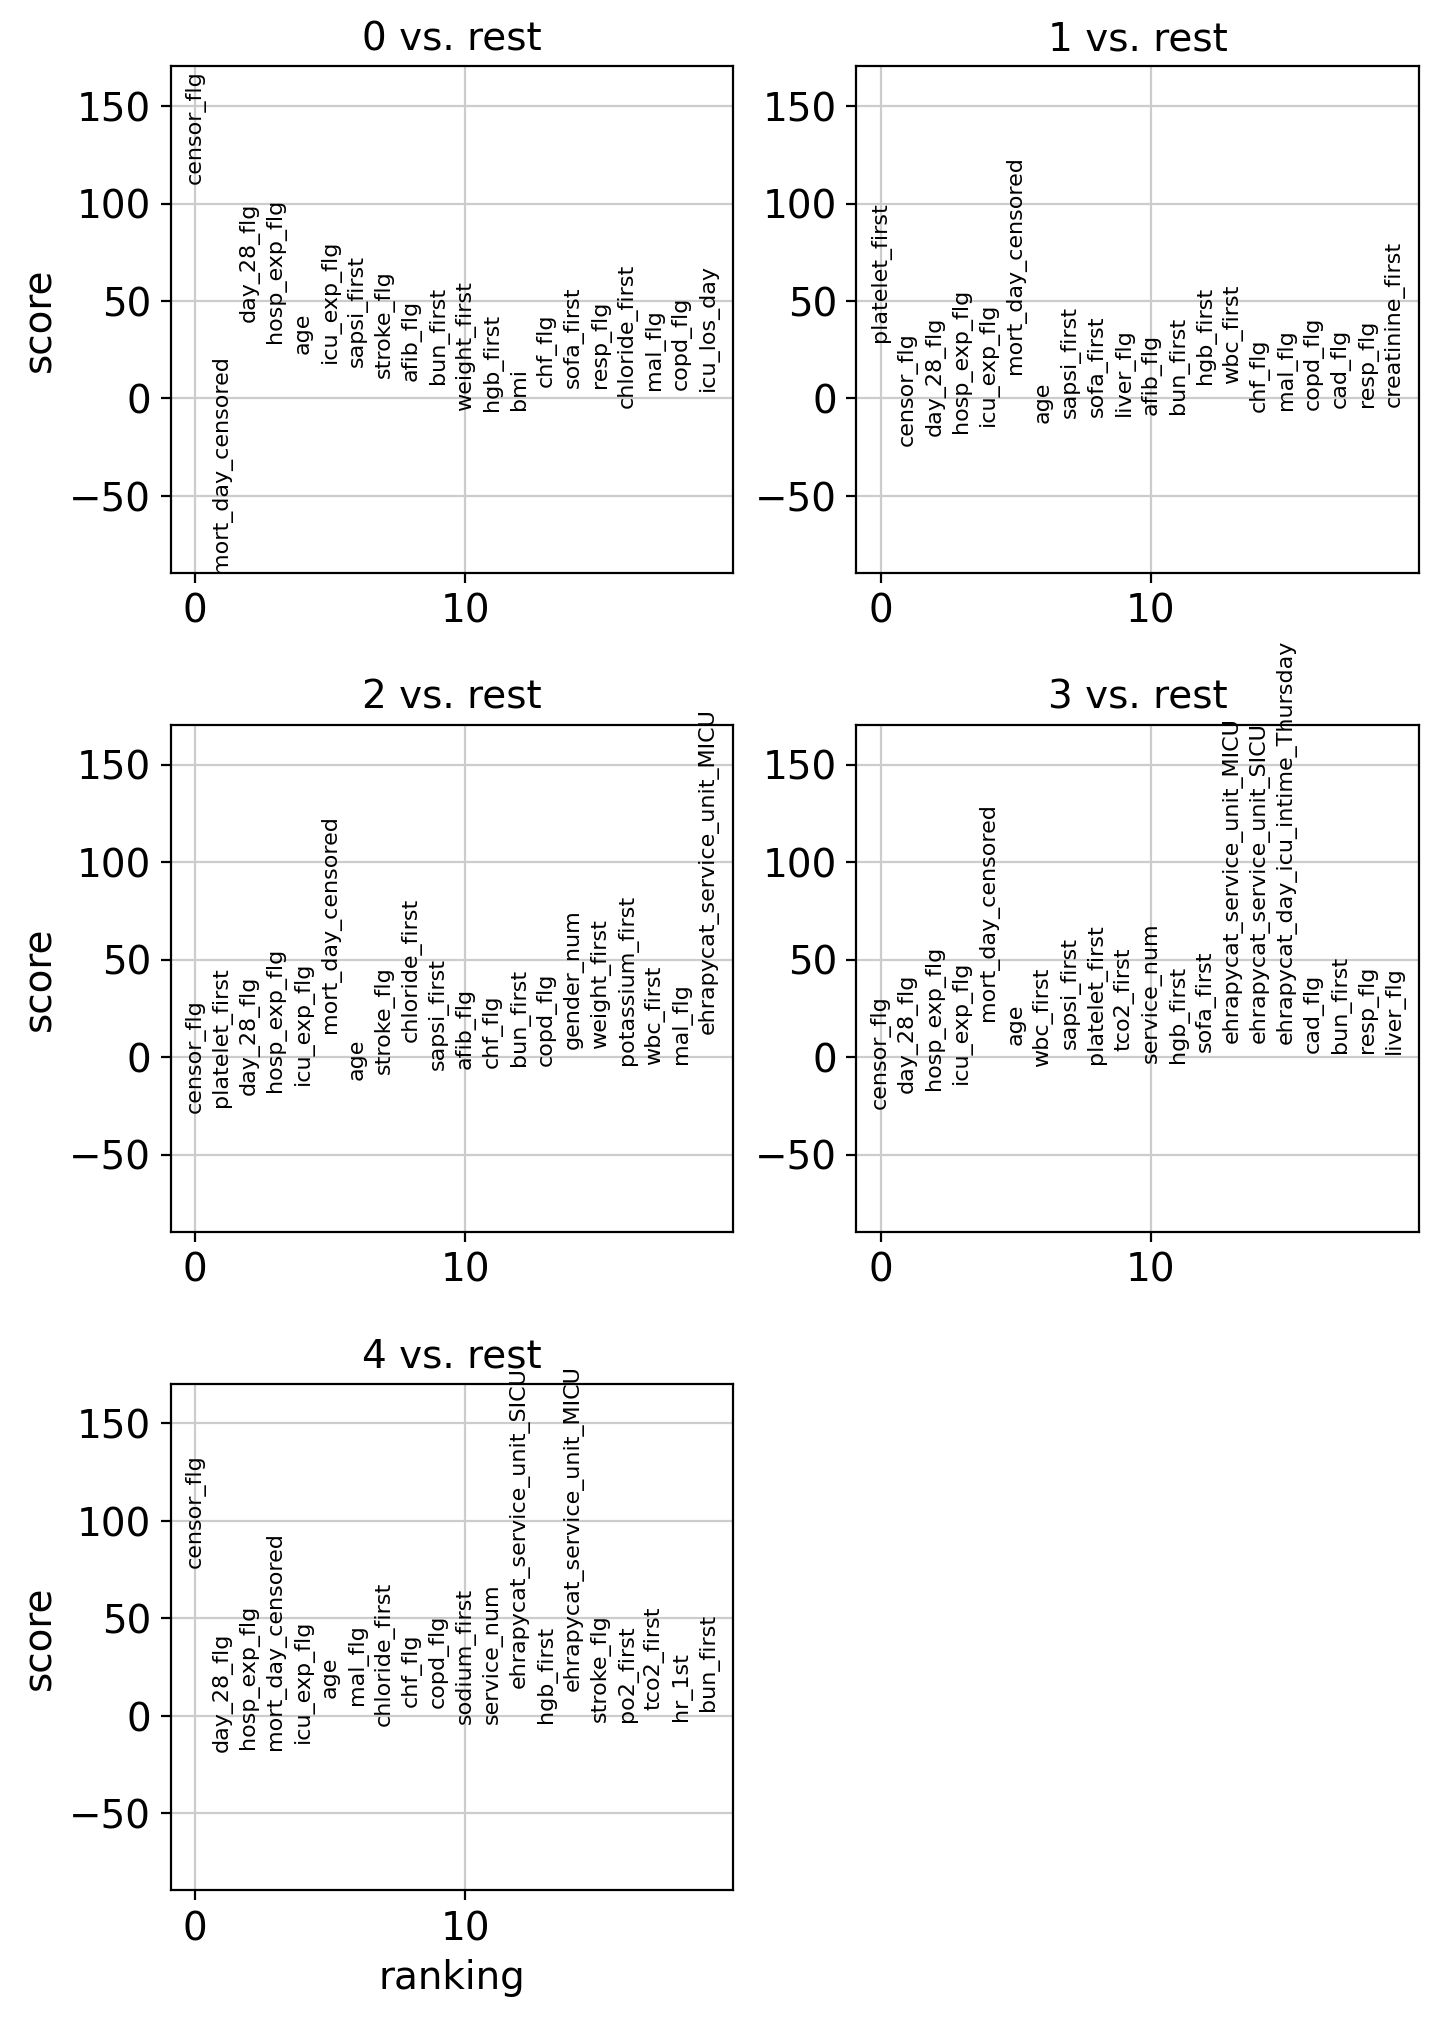

In [45]:
plt.rcParams["figure.figsize"] = (4, 4)
plt.rcParams["figure.dpi"] = 100
ep.pl.rank_features_groups(edata, key="rank_features_groups", ncols=2)

We can also get the top features per cluster as a DataFrame.

In [52]:
df = ep.get.rank_features_groups_df(edata, group=list(edata.obs["leiden_0_3"].unique()))
df = df.loc[(df["logfoldchanges"] > 0) & (df["pvals_adj"] < 0.05),]

E.g. we can check the top marker of cluster 2.

In [53]:
df.loc[df["group"] == "2",]

,group,names,scores,logfoldchanges,pvals,pvals_adj
113,2,mort_day_censored,12.560957,inf,5.805679e-34,5.225111e-33
116,2,chloride_first,8.095436,3.198010,1.224180e-15,7.345083e-15
122,2,gender_num,4.309914,0.334411,1.747495e-05,6.290980e-05
123,2,weight_first,4.191347,6.553209,2.958168e-05,9.983817e-05
127,2,ehrapycat_service_unit_MICU,11.939801,1.000000,5.494735e-04,1.483579e-03
129,2,liver_flg,3.319525,1.026702,9.328513e-04,2.190173e-03
131,2,iv_day_1,3.197073,0.415858,1.420306e-03,3.195689e-03
132,2,sodium_first,3.142164,1.009302,1.709263e-03,3.692008e-03
133,2,service_num,2.952070,0.241071,3.210079e-03,6.667087e-03
134,2,ehrapycat_service_unit_SICU,8.342188,1.000000,3.873493e-03,7.746986e-03


From this table we can also extract the top features in every cluster and highlight those either on the UMAP or as violins plots by cluster.

In [54]:
top_features = df.groupby("group").head(5)
top_features = pd.Series(top_features["names"].unique())
top_features

0                      censor_flg
1                      day_28_flg
2                    hosp_exp_flg
3                             age
4                     icu_exp_flg
5                  platelet_first
6               mort_day_censored
7                       hgb_first
8                       wbc_first
9                          hr_1st
10                 chloride_first
11                     gender_num
12                   weight_first
13    ehrapycat_service_unit_MICU
14                    sapsi_first
15                     tco2_first
16                     sofa_first
17                        mal_flg
18                        chf_flg
19                       copd_flg
dtype: object

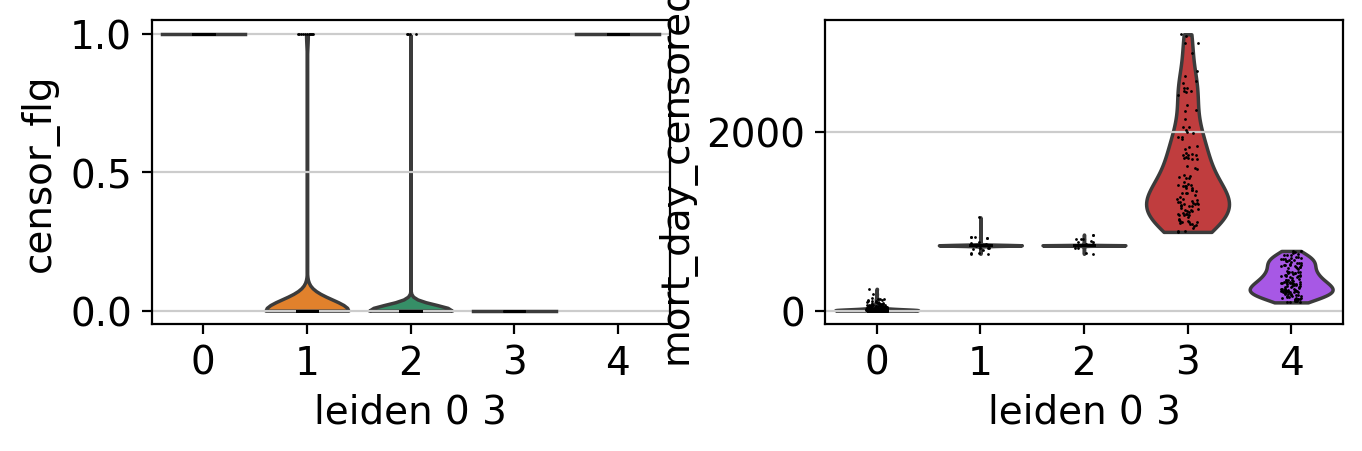

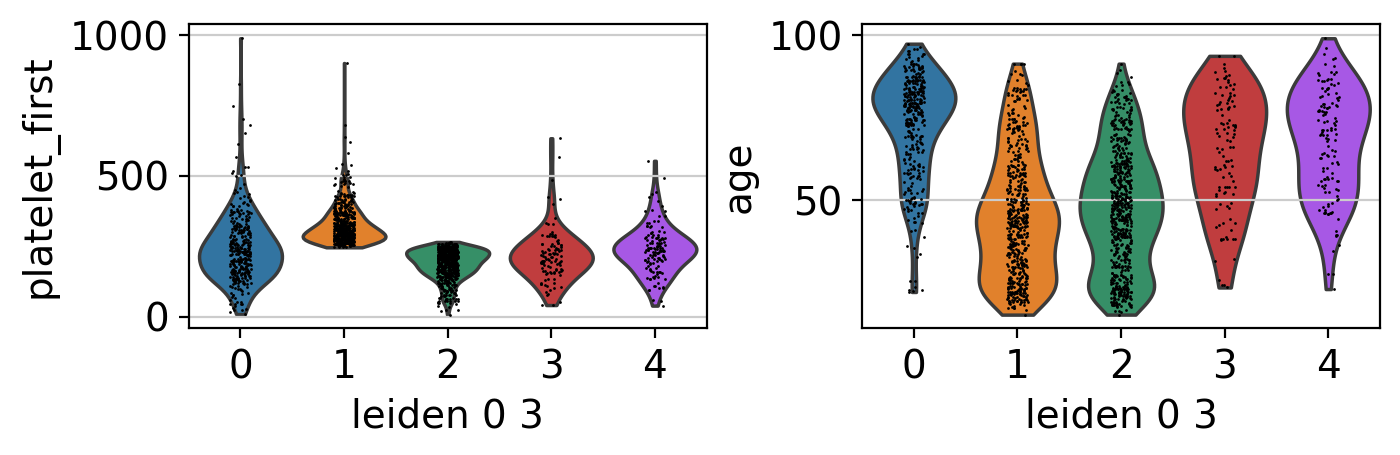

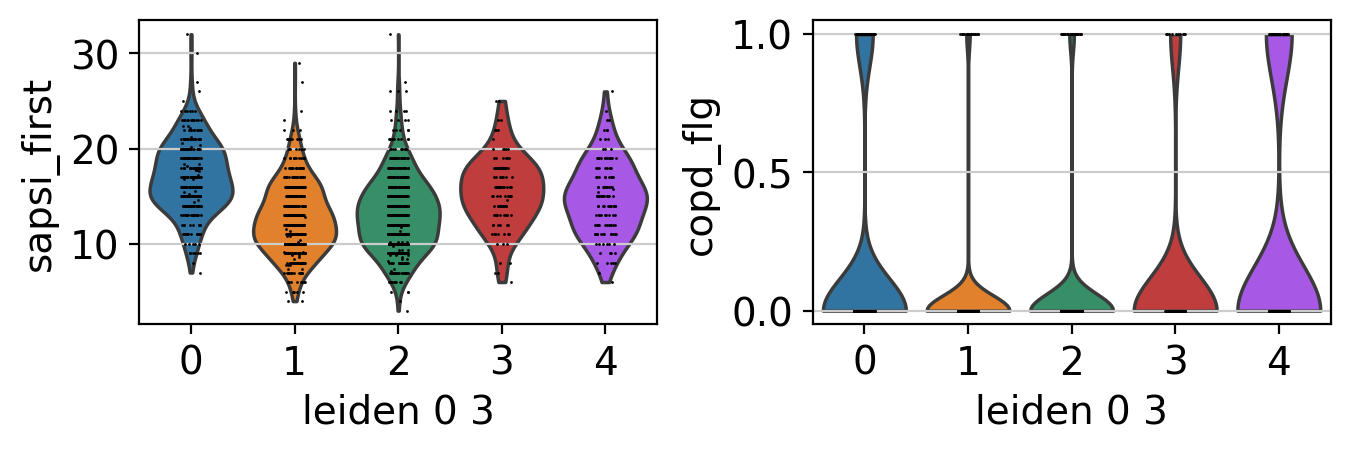

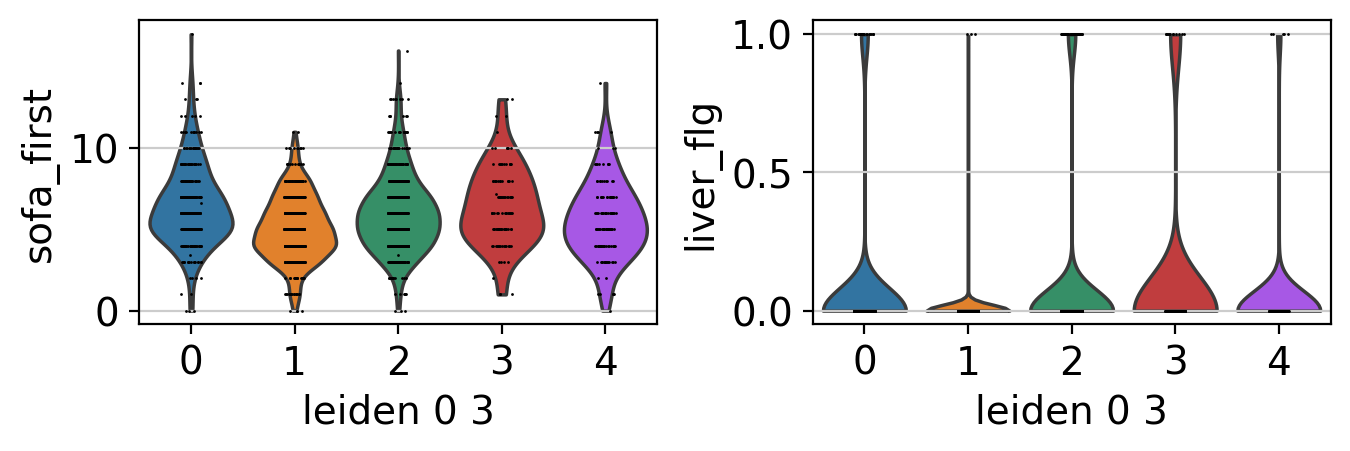

In [55]:
plt.rcParams["figure.figsize"] = (3.8, 2)
plt.rcParams["figure.dpi"] = 100
ep.pl.violin(edata, keys=["censor_flg", "mort_day_censored"], groupby="leiden_0_3")
ep.pl.violin(edata, keys=["platelet_first", "age"], groupby="leiden_0_3")
ep.pl.violin(edata, keys=["sapsi_first", "copd_flg"], groupby="leiden_0_3")
ep.pl.violin(edata, keys=["sofa_first", "liver_flg"], groupby="leiden_0_3")

#### Cluster annotation

With the knowledge of the cluster features, together with the UMAP plots from above we can annotate the clusters.

In [56]:
edata.obs["annotation"] = "NA"

In [57]:
annotation = {
    "0": "liver+/sofa+",
    "1": "weight+",
    "2": "age+/stroke+/deceased+",
    "3": "platelet+",
    "4": "age+/malignancy+/copd+/deceased+",
    "5": "age+",
}

In [58]:
edata.obs["annotation"] = [annotation[l] if l in annotation.keys() else l for l in edata.obs["leiden_0_3"]]

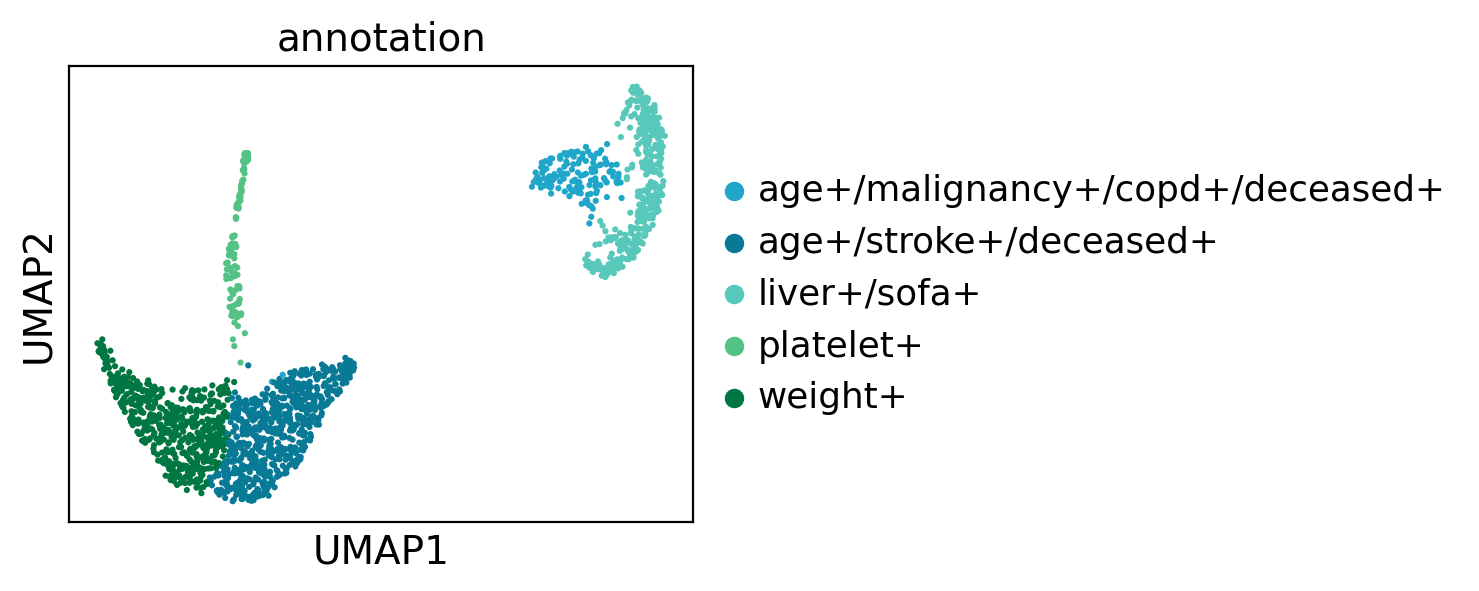

In [59]:
plt.rcParams["figure.figsize"] = (4, 3)
plt.rcParams["figure.dpi"] = 100
ep.pl.umap(
    edata,
    color="annotation",
    size=20,
    palette={
        "weight+": "#007742",
        "platelet+": "#54C285",
        "age+/stroke+/deceased+": "#087A96",
        "age+/malignancy+/copd+/deceased+": "#1FA6C9",
        "age+": "#F4CC47",
        "liver+/sofa+": "#57C8B9",
        "platelet+/heart_rate+": "#ABEC7D",
    },
)

### Additional downstream analysis 

After these basic ehrapy analysis steps, additional downstream analysis can be performed (see also other tutorials). 

#### PAGA

It might also be of interest to infer trajectories to learn about dynamic processes and stage transitions.
ehrapy offers several [trajectory inference](https://ehrapy.readthedocs.io/en/latest/usage/usage.html#clustering-and-trajectory-inference) algorithms for this purpose. One of those is partition-based graph abstraction (PAGA).

In [60]:
ep.tl.paga(edata, groups="leiden_0_3")

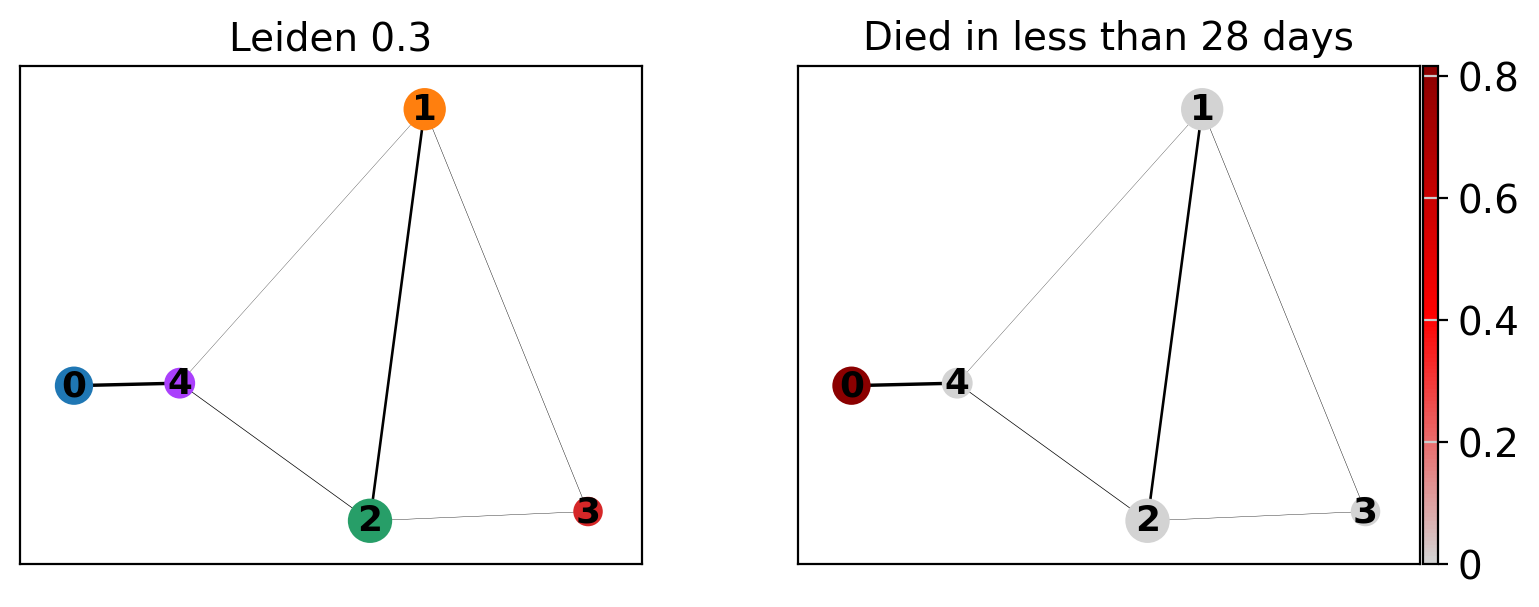

In [61]:
ep.pl.paga(
    edata,
    color=["leiden_0_3", "day_28_flg"],
    cmap=ep.pl.Colormaps.grey_red.value,
    title=["Leiden 0.3", "Died in less than 28 days"],
)

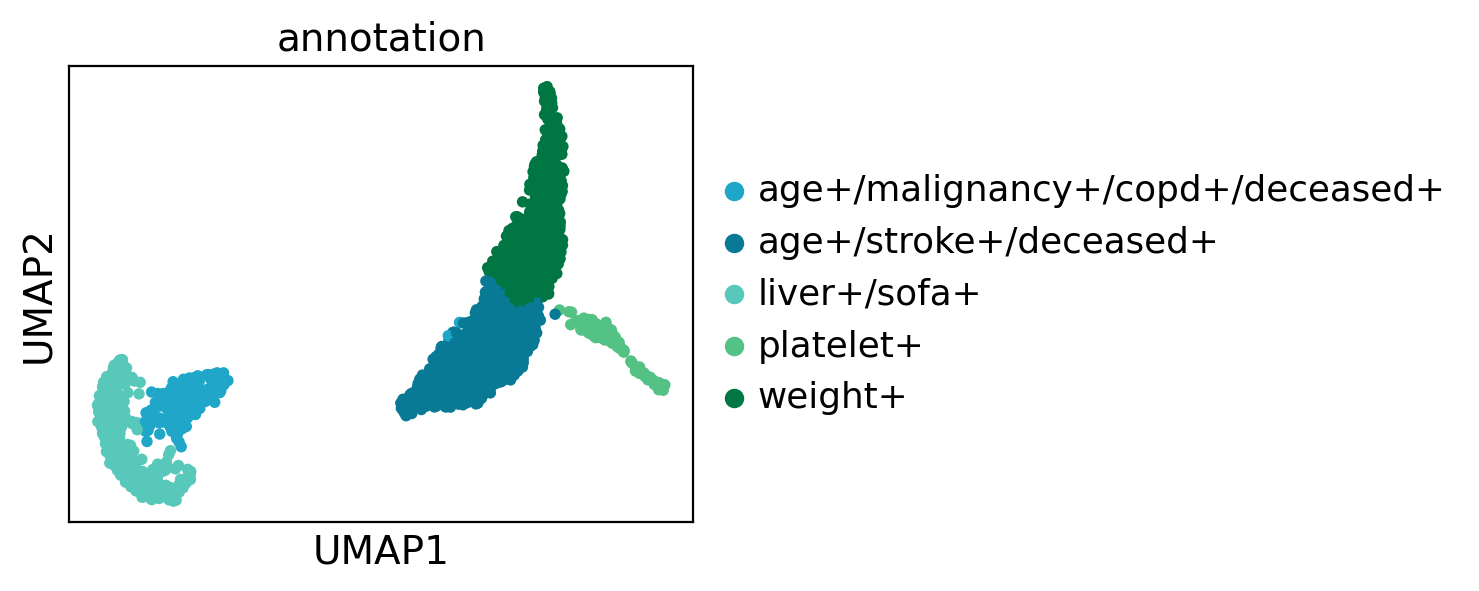

In [62]:
ep.tl.umap(edata, init_pos="paga")
ep.pl.umap(edata, color=["annotation"])

In [63]:
ep.tl.draw_graph(edata, init_pos="paga")

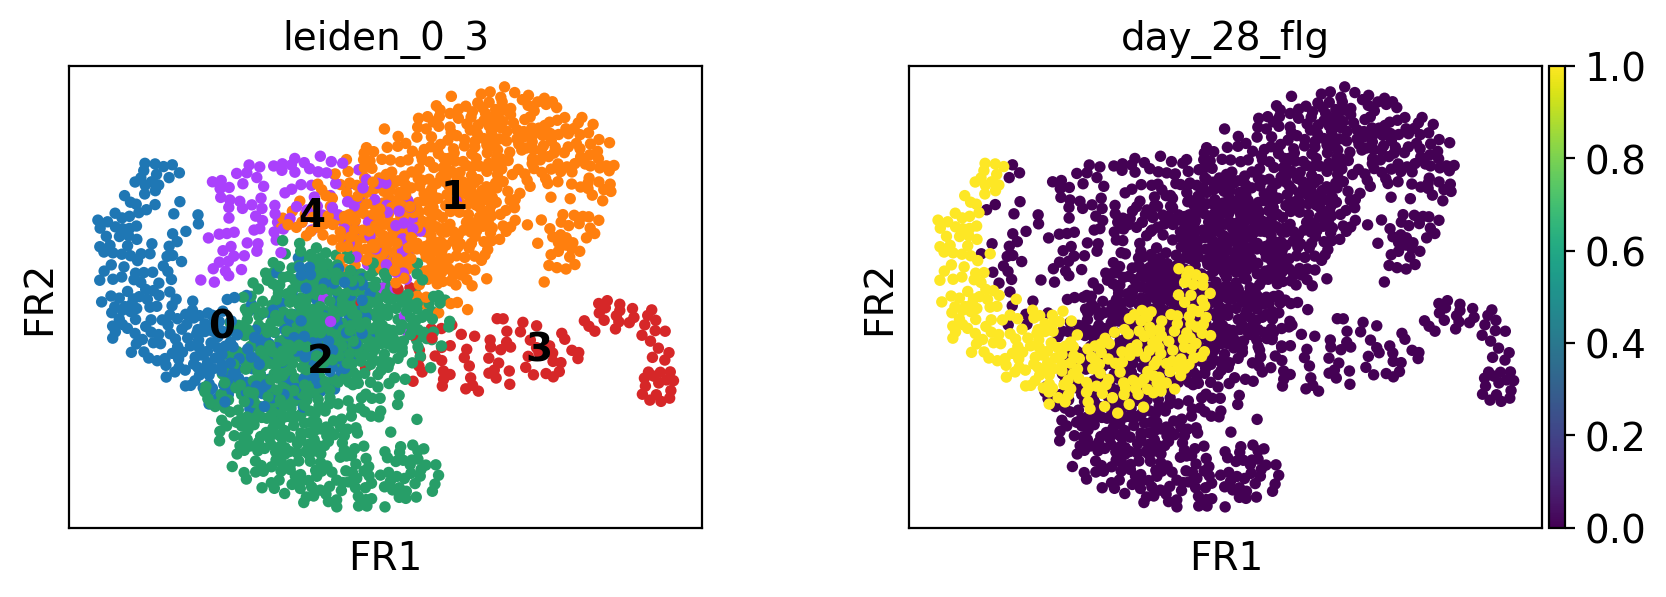

In [64]:
ep.tl.draw_graph(edata, init_pos="paga")
ep.pl.draw_graph(edata, color=["leiden_0_3", "day_28_flg"], legend_loc="on data")

_________________

## Exporting results

We save all of our computations and our final state into an `.h5ed` file.
It can then be read again using `ed.io.read_h5ed`.

In [65]:
ed.io.write_h5ed(edata, "mimic_2.h5ed")

_________________

## Conclusion

The MIMIC-II IAC dataset comprises electronic health records (EHR) summarized in 46 features from 1776 individuals. This high dimensional data is not easy to interpret and many interesting and previously unknown features can be overseen when just focusing on selected well-defined features. To overcome this hurdle, we applied ehrapy on the MIMIC-II IAC dataset. 

ehrapy is based on the EHRData data structure and scanpy pipeline to allow for efficient analysis. We used the build-in functions to preprocess the data, perform QC with imputation of missing data and reduce the dimensionality, resulting in PCA and UMAP embeddings.
After performing all these steps, we explored the data by visualizing multiple features on the UMAP embedding, giving a first glance at the patient structure. 
To identify patient groups in and unbiased fashion, we clustered our data using the Leiden algorithm resulting in 7 different patient clusters.
Calculation of cluster-specific features allowed us to annotate the clusters according to the most prominent markers.
We saw a strong difference between patients that deceased, had higher age and severe comorbidities such as a stroke and COPD (clusters 2+3) and those that had milder features such as increased platelets and weight (clusters 0+1).
Close to these two clusters were two additional clusters that harbored more severe features such as increased heart rate (cluster 5) and high SOFA score with liver disease (cluster 6), indicating potential patient trajectories.
Cluster 4 clustered apart from all the others and consists of patients that deceased several months/years after leaving the ICU. 

To explore the [patient fate](https://ehrapy.readthedocs.io/en/latest/tutorials/notebooks/mimic_2_fate.html),  [survival](https://ehrapy.readthedocs.io/en/latest/tutorials/notebooks/mimic_2_survival_analysis.html) and a [case study](https://ehrapy.readthedocs.io/en/latest/tutorials/notebooks/mimic_2_case_study.html) in more detail, continue with our other tutorials or go back to our [tutorial overview page](https://ehrapy.readthedocs.io/en/latest/tutorials/index.html). 

_________________

## References

* Raffa, J. (2016). Clinical data from the MIMIC-II database for a case study on indwelling arterial catheters (version 1.0). PhysioNet. https://doi.org/10.13026/C2NC7F.

* Raffa J.D., Ghassemi M., Naumann T., Feng M., Hsu D. (2016) Data Analysis. In: Secondary Analysis of Electronic Health Records. Springer, Cham

* Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220.

* McInnes et al., (2018). UMAP: Uniform Manifold Approximation and Projection. Journal of Open Source Software, 3(29), 861, https://doi.org/10.21105/joss.00861

* Traag, V.A., Waltman, L. & van Eck, N.J. From Louvain to Leiden: guaranteeing well-connected communities. Sci Rep 9, 5233 (2019). https://doi.org/10.1038/s41598-019-41695-z

* Wolf, F.A., Hamey, F.K., Plass, M. et al. PAGA: graph abstraction reconciles clustering with trajectory inference through a topology preserving map of single cells. Genome Biol 20, 59 (2019). https://doi.org/10.1186/s13059-019-1663-x

## Package versions

In [67]:
!pip list

Package                   Version      Build Editable project location
------------------------- ------------ ----- -----------------------------------------------------------------
aiobotocore               3.2.1
aiofiles                  25.1.0
aiohappyeyeballs          2.6.1
aiohttp                   3.13.3
aioitertools              0.13.0
aiosignal                 1.4.0
anndata                   0.12.10
anyio                     4.12.1
anywidget                 0.9.21
appdirs                   1.4.4
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
array-api-compat          1.14.0
arrow                     1.4.0
asgiref                   3.11.1
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
autograd                  1.8.0
autograd-gamma            0.5.0
babel                     2.18.0
beautifulsoup4            4.14.3
black                     26.3.1
bleach                    6.3.0
bokeh                     3.8.2
bot